# 02 - ABSA BERT + TextCNN, modelos comparativos, inferencia y matriz destino-aspecto

Este notebook corresponde a la **Fase 2 v3**. Usa el `gold_set_final.csv` generado por el notebook 01 y entrena el modelo ABSA principal.

Flujo completo:

1. Cargar `gold_set_final.csv` y splits `train/validation/test`.
2. Analizar la distribución del gold set por polaridad, aspecto, destino e idioma.
3. Entrenar modelos comparativos clásicos con TF-IDF.
4. Entrenar **BERT multilingual + TextCNN**.
5. Evaluar con `accuracy`, `precision`, `recall`, **F1 macro**, matriz de confusión y curvas ROC/AUC.
6. Comparar BERT + TextCNN contra los modelos base.
7. Analizar desempeño por aspecto y errores frecuentes.
8. Aplicar el modelo sobre `tourism_reviews_clean.csv` de Fase 1.
9. Generar `predicciones_absa.csv`, `tuplas_absa.csv`, `matriz_absa_detallada.csv` y `matriz_absa_normalizada.csv`.

> Nota metodológica: el modelo se entrena con etiquetas humanas finales, no con polaridad por estrellas ni con etiquetas automáticas.

In [1]:
# ============================================================
# 1. Librerías, rutas y configuración general
# ============================================================

from pathlib import Path
from collections import Counter
import json
import math
import random
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except Exception as e:
    raise ImportError("Falta matplotlib. Instala con: pip install matplotlib") from e

try:
    from sklearn.dummy import DummyClassifier
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.naive_bayes import MultinomialNB, ComplementNB
    from sklearn.svm import LinearSVC
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import (
        accuracy_score,
        precision_recall_fscore_support,
        classification_report,
        confusion_matrix,
        roc_curve,
        auc,
    )
    from sklearn.preprocessing import label_binarize
except Exception as e:
    raise ImportError("Falta scikit-learn. Instala con: pip install scikit-learn") from e

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except Exception as e:
    raise ImportError("Falta PyTorch. Instala torch según tu entorno/GPU.") from e

try:
    from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
except Exception as e:
    raise ImportError("Falta transformers. Instala con: pip install transformers") from e

try:
    from tqdm.auto import tqdm
except Exception as e:
    raise ImportError("Falta tqdm. Instala con: pip install tqdm") from e

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
REPORTS_DIR = OUTPUT_DIR / "reports"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
MATRICES_DIR = OUTPUT_DIR / "matrices"
VIS_DIR = OUTPUT_DIR / "visualizations"
MODELS_DIR = BASE_DIR / "models"

for folder in [DATA_DIR, OUTPUT_DIR, REPORTS_DIR, PREDICTIONS_DIR, MATRICES_DIR, VIS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("DEVICE:", DEVICE)

BASE_DIR: d:\Tesis\ABSA_Turismo_Fase2_V3
DATA_DIR: d:\Tesis\ABSA_Turismo_Fase2_V3\data
OUTPUT_DIR: d:\Tesis\ABSA_Turismo_Fase2_V3\outputs
DEVICE: cuda


In [2]:
# ============================================================
# 2. Parámetros del experimento
# ============================================================

MODEL_NAME = "bert-base-multilingual-cased"
MAX_LEN = 256
BATCH_SIZE = 4
EPOCHS = 10
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.10
WARMUP_RATIO = 0.10
PATIENCE = 2
FOCAL_GAMMA = 0.0   # 0 = CrossEntropy normal (mejor modelo); 2.0 enfoca casos dificiles

CNN_NUM_FILTERS = 128
CNN_KERNEL_SIZES = [2, 3, 4]
DROPOUT = 0.45

# Experimento de ablacion: True = input 'aspecto: X reseña: ...' | False = solo el texto
USE_ASPECT_TOKEN = True

VALID_LABELS = ["negativo", "neutro", "positivo"]
LABEL_TO_ID = {label: idx for idx, label in enumerate(VALID_LABELS)}
ID_TO_LABEL = {idx: label for label, idx in LABEL_TO_ID.items()}
SCORE_BY_LABEL = {"negativo": -1, "neutro": 0, "positivo": 1}

VALID_ASPECTS = [
    "atractivos",
    "costos",
    "seguridad",
    "accesibilidad",
    "limpieza",
    "atencion_servicio",
    "gastronomia",
    "alojamiento",
    "clima",
    "aforo_multitudes",
]

# Para pruebas rápidas, cambia DEBUG_SAMPLE a True.
DEBUG_SAMPLE = False
DEBUG_N_ROWS = 300

print("Etiquetas:", LABEL_TO_ID)
print("Aspectos válidos:", VALID_ASPECTS)

Etiquetas: {'negativo': 0, 'neutro': 1, 'positivo': 2}
Aspectos válidos: ['atractivos', 'costos', 'seguridad', 'accesibilidad', 'limpieza', 'atencion_servicio', 'gastronomia', 'alojamiento', 'clima', 'aforo_multitudes']


In [3]:
# ============================================================
# 3. Utilidades de lectura y validación
# ============================================================

def find_file(filename: str, preferred_dirs=None) -> Path:
    """Busca un archivo en data/, outputs/ y /mnt/data como respaldo."""
    if preferred_dirs is None:
        preferred_dirs = [DATA_DIR, OUTPUT_DIR, BASE_DIR, Path("/mnt/data"), Path("/mnt/data/data"), Path("/mnt/data/outputs")]
    for folder in preferred_dirs:
        path = folder / filename
        if path.exists():
            return path
    raise FileNotFoundError(f"No se encontró {filename}. Colócalo en data/ u outputs/.")


def normalize_label(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    mapping = {
        "positiva": "positivo", "positivo": "positivo", "pos": "positivo", "+": "positivo",
        "neutral": "neutro", "neutra": "neutro", "neutro": "neutro", "nuetro": "neutro",
        "negativa": "negativo", "negativo": "negativo", "neg": "negativo", "-": "negativo",
    }
    return mapping.get(value, value)


def normalize_aspect(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    mapping = {
        "atención_servicio": "atencion_servicio",
        "atencion servicio": "atencion_servicio",
        "atencion/servicio": "atencion_servicio",
        "aforo multitudes": "aforo_multitudes",
        "aforo/multitudes": "aforo_multitudes",
        "atractivo": "atractivos",
    }
    return mapping.get(value, value)


def ensure_input_modelo(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if not USE_ASPECT_TOKEN:
        df["input_modelo"] = df["text_clean"].astype(str)
        return df
    if "input_modelo" not in df.columns or df["input_modelo"].isna().all():
        df["input_modelo"] = "aspecto: " + df["aspecto"].astype(str) + " reseña: " + df["text_clean"].astype(str)
    else:
        missing = df["input_modelo"].isna() | (df["input_modelo"].astype(str).str.strip() == "")
        df.loc[missing, "input_modelo"] = (
            "aspecto: " + df.loc[missing, "aspecto"].astype(str) +
            " reseña: " + df.loc[missing, "text_clean"].astype(str)
        )
    return df


def evaluate_predictions(y_true, y_pred, prefix=""):
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=VALID_LABELS, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=VALID_LABELS, average="weighted", zero_division=0
    )
    return {
        "modelo": prefix,
        "accuracy": round(acc, 4),
        "precision_macro": round(precision_macro, 4),
        "recall_macro": round(recall_macro, 4),
        "f1_macro": round(f1_macro, 4),
        "precision_weighted": round(precision_weighted, 4),
        "recall_weighted": round(recall_weighted, 4),
        "f1_weighted": round(f1_weighted, 4),
    }

In [4]:
# ============================================================
# 4. Carga del gold set final y splits
# ============================================================

GOLD_SET_FILE = find_file("gold_set_final.csv")
TRAIN_FILE = find_file("train.csv")
VALIDATION_FILE = find_file("validation.csv")
TEST_FILE = find_file("test.csv")

print("Gold set:", GOLD_SET_FILE)
print("Train:", TRAIN_FILE)
print("Validation:", VALIDATION_FILE)
print("Test:", TEST_FILE)

gold_set = pd.read_csv(GOLD_SET_FILE, encoding="utf-8-sig")
train_df = pd.read_csv(TRAIN_FILE, encoding="utf-8-sig")
validation_df = pd.read_csv(VALIDATION_FILE, encoding="utf-8-sig")
test_df = pd.read_csv(TEST_FILE, encoding="utf-8-sig")

required_cols = ["review_uid", "destination", "aspecto", "text_clean", "input_modelo", "label"]
for name, df in [("gold_set", gold_set), ("train", train_df), ("validation", validation_df), ("test", test_df)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} no tiene columnas obligatorias: {missing}")
    df["label"] = df["label"].apply(normalize_label)
    df["aspecto"] = df["aspecto"].apply(normalize_aspect)
    invalid_labels = df.loc[~df["label"].isin(VALID_LABELS), "label"].unique().tolist()
    invalid_aspects = df.loc[~df["aspecto"].isin(VALID_ASPECTS), "aspecto"].unique().tolist()
    if invalid_labels:
        raise ValueError(f"{name} tiene labels inválidos: {invalid_labels}")
    if invalid_aspects:
        raise ValueError(f"{name} tiene aspectos inválidos: {invalid_aspects}")

    df.dropna(subset=["review_uid", "text_clean", "aspecto", "label"], inplace=True)
    df["text_clean"] = df["text_clean"].astype(str)
    df["aspecto"] = df["aspecto"].astype(str)
    df["label"] = df["label"].astype(str)

train_df = ensure_input_modelo(train_df)
validation_df = ensure_input_modelo(validation_df)
test_df = ensure_input_modelo(test_df)
gold_set = ensure_input_modelo(gold_set)

if DEBUG_SAMPLE:
    train_df = train_df.sample(min(DEBUG_N_ROWS, len(train_df)), random_state=SEED).reset_index(drop=True)
    validation_df = validation_df.sample(min(max(50, DEBUG_N_ROWS // 5), len(validation_df)), random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(min(max(50, DEBUG_N_ROWS // 5), len(test_df)), random_state=SEED).reset_index(drop=True)

# Validar que no haya fuga por review_uid entre splits
assert set(train_df["review_uid"]).isdisjoint(set(validation_df["review_uid"])), "Leakage train-validation."
assert set(train_df["review_uid"]).isdisjoint(set(test_df["review_uid"])), "Leakage train-test."
assert set(validation_df["review_uid"]).isdisjoint(set(test_df["review_uid"])), "Leakage validation-test."

print("Gold set:", gold_set.shape)
print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

distribution = pd.concat([
    train_df.assign(split="train"),
    validation_df.assign(split="validation"),
    test_df.assign(split="test"),
]).groupby(["split", "label"]).size().reset_index(name="cantidad")

distribution.to_csv(REPORTS_DIR / "distribucion_splits_absa.csv", index=False, encoding="utf-8-sig")
display(distribution)

Gold set: d:\Tesis\ABSA_Turismo_Fase2_V3\data\gold_set_final.csv
Train: d:\Tesis\ABSA_Turismo_Fase2_V3\data\train.csv
Validation: d:\Tesis\ABSA_Turismo_Fase2_V3\data\validation.csv
Test: d:\Tesis\ABSA_Turismo_Fase2_V3\data\test.csv
Gold set: (2776, 10)
Train: (1912, 10)
Validation: (443, 10)
Test: (421, 10)


,split,label,cantidad
0,test,negativo,85
1,test,neutro,146
2,test,positivo,190
3,train,negativo,386
4,train,neutro,685
5,train,positivo,841
6,validation,negativo,71
7,validation,neutro,177
8,validation,positivo,195


,dataset,filas,reseñas_unicas,destinos,aspectos,negativo,neutro,positivo
0,gold_set,2776,1051,10,10,542,1008,1226
1,train,1912,735,10,10,386,685,841
2,validation,443,158,10,10,71,177,195
3,test,421,158,10,10,85,146,190


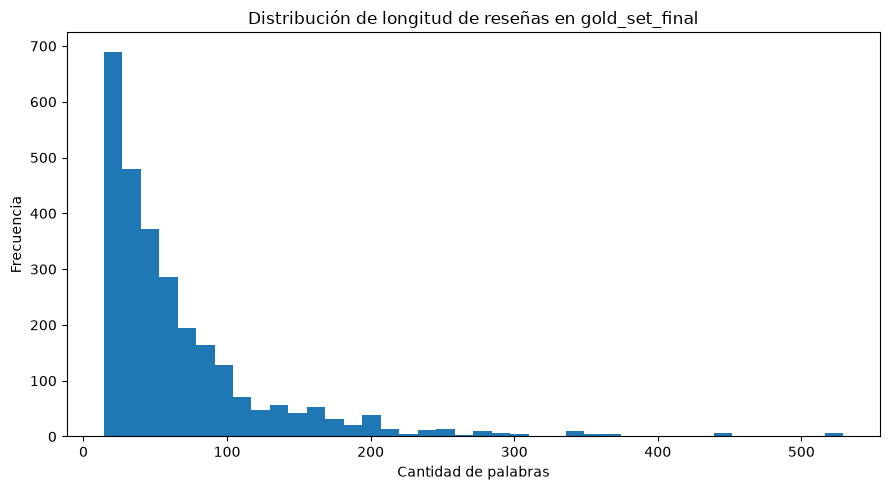

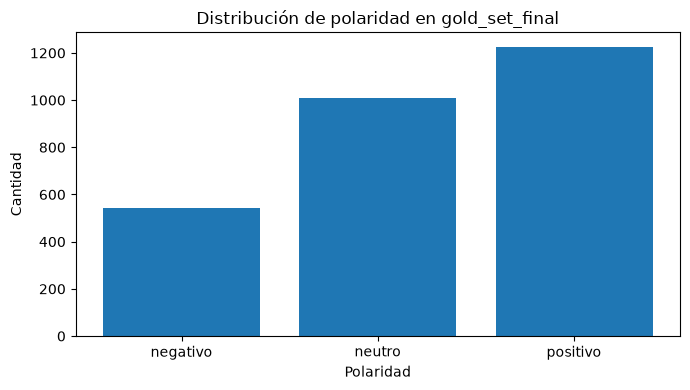

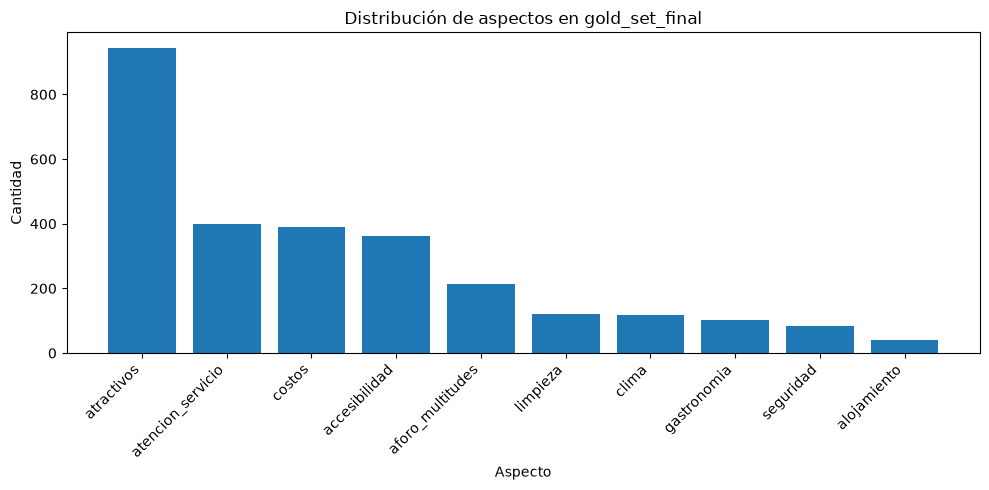

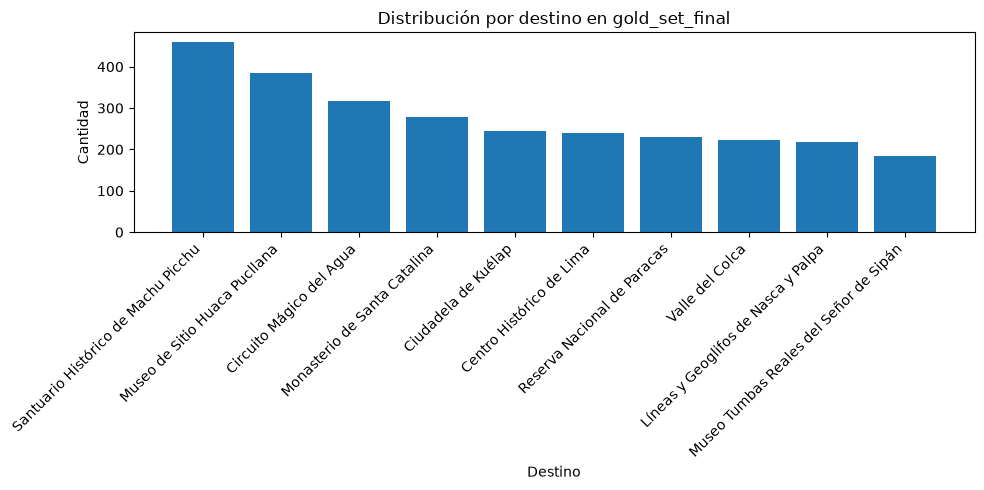

label,negativo,neutro,positivo
aspecto,,,
accesibilidad,76,205,81
aforo_multitudes,106,87,20
alojamiento,2,25,12
atencion_servicio,43,255,102
atractivos,146,80,719
clima,51,42,26
costos,56,183,151
gastronomia,4,74,25
limpieza,25,36,59


,split,label,cantidad
0,train,negativo,386
1,train,neutro,685
2,train,positivo,841
3,validation,negativo,71
4,validation,neutro,177
5,validation,positivo,195
6,test,negativo,85
7,test,neutro,146
8,test,positivo,190


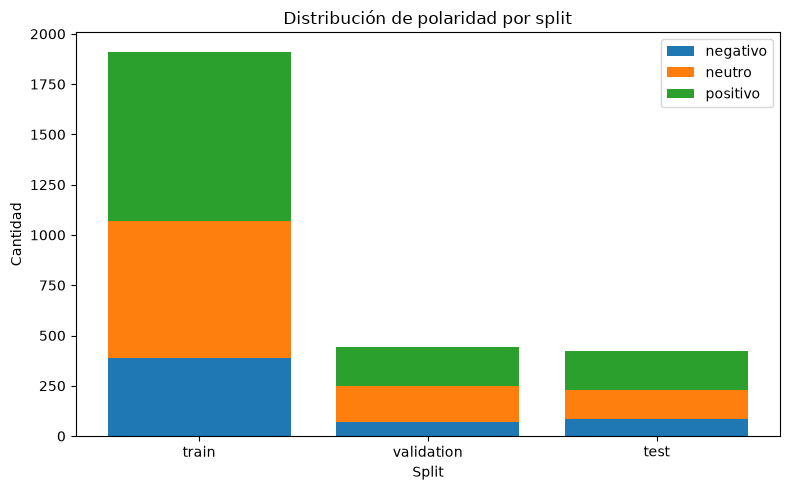

In [5]:

# ============================================================
# 5. Análisis exploratorio del gold set y splits
# ============================================================

summary_rows = []
for name, df in [("gold_set", gold_set), ("train", train_df), ("validation", validation_df), ("test", test_df)]:
    summary_rows.append({
        "dataset": name,
        "filas": len(df),
        "reseñas_unicas": df["review_uid"].nunique(),
        "destinos": df["destination"].nunique(),
        "aspectos": df["aspecto"].nunique(),
        "negativo": int((df["label"] == "negativo").sum()),
        "neutro": int((df["label"] == "neutro").sum()),
        "positivo": int((df["label"] == "positivo").sum()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(REPORTS_DIR / "resumen_gold_set_y_splits.csv", index=False, encoding="utf-8-sig")
display(summary_df)

# Longitud de textos
gold_set["num_words"] = gold_set["text_clean"].astype(str).str.split().str.len()
plt.figure(figsize=(9, 5))
plt.hist(gold_set["num_words"], bins=40)
plt.title("Distribución de longitud de reseñas en gold_set_final")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(VIS_DIR / "distribucion_longitud_gold_set.png", dpi=180)
plt.show()

# Distribución de polaridad
label_counts = gold_set["label"].value_counts().reindex(VALID_LABELS).fillna(0)
plt.figure(figsize=(7, 4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Distribución de polaridad en gold_set_final")
plt.xlabel("Polaridad")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.savefig(VIS_DIR / "distribucion_labels_gold_set.png", dpi=180)
plt.show()

# Distribución por aspecto
aspect_counts = gold_set["aspecto"].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(aspect_counts.index, aspect_counts.values)
plt.title("Distribución de aspectos en gold_set_final")
plt.xlabel("Aspecto")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(VIS_DIR / "distribucion_aspectos_gold_set.png", dpi=180)
plt.show()

# Distribución por destino
dest_counts = gold_set["destination"].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(dest_counts.index, dest_counts.values)
plt.title("Distribución por destino en gold_set_final")
plt.xlabel("Destino")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(VIS_DIR / "distribucion_destinos_gold_set.png", dpi=180)
plt.show()

# Tabla aspecto x polaridad
aspect_label_table = pd.crosstab(gold_set["aspecto"], gold_set["label"]).reindex(columns=VALID_LABELS).fillna(0).astype(int)
aspect_label_table.to_csv(REPORTS_DIR / "distribucion_aspecto_label_gold_set.csv", encoding="utf-8-sig")
display(aspect_label_table)

# Distribución de polaridad por split
split_rows = []
for name, df in [("train", train_df), ("validation", validation_df), ("test", test_df)]:
    counts = df["label"].value_counts().reindex(VALID_LABELS).fillna(0)
    for label, count in counts.items():
        split_rows.append({"split": name, "label": label, "cantidad": int(count)})

split_dist = pd.DataFrame(split_rows)
split_dist.to_csv(REPORTS_DIR / "distribucion_labels_por_split.csv", index=False, encoding="utf-8-sig")
display(split_dist)

pivot_split = split_dist.pivot(index="split", columns="label", values="cantidad").reindex(["train", "validation", "test"])
plt.figure(figsize=(8, 5))
bottom = np.zeros(len(pivot_split))
for label in VALID_LABELS:
    values = pivot_split[label].values
    plt.bar(pivot_split.index, values, bottom=bottom, label=label)
    bottom += values
plt.title("Distribución de polaridad por split")
plt.xlabel("Split")
plt.ylabel("Cantidad")
plt.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "distribucion_labels_por_split.png", dpi=180)
plt.show()


In [6]:

# ============================================================
# 6. Baselines ML clásicos para comparación
# ============================================================

X_train = train_df["input_modelo"].astype(str).tolist()
y_train = train_df["label"].astype(str).tolist()
X_val = validation_df["input_modelo"].astype(str).tolist()
y_val = validation_df["label"].astype(str).tolist()
X_test = test_df["input_modelo"].astype(str).tolist()
y_test = test_df["label"].astype(str).tolist()

baseline_rows = []
baseline_predictions = []
baseline_scores_for_roc = {}

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=30000,
    sublinear_tf=True,
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

baseline_models = {
    "majority_class": DummyClassifier(strategy="most_frequent", random_state=SEED),
    "tfidf_logistic_regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED),
    "tfidf_linear_svm": LinearSVC(class_weight="balanced", random_state=SEED),
    "tfidf_naive_bayes": MultinomialNB(),
    "tfidf_complement_nb": ComplementNB(),
    "tfidf_random_forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=SEED, n_jobs=-1),
}

for model_name, model in baseline_models.items():
    if model_name == "majority_class":
        model.fit(np.zeros((len(y_train), 1)), y_train)
        val_preds = model.predict(np.zeros((len(y_val), 1)))
        test_preds = model.predict(np.zeros((len(y_test), 1)))
    else:
        model.fit(X_train_tfidf, y_train)
        val_preds = model.predict(X_val_tfidf)
        test_preds = model.predict(X_test_tfidf)

    val_metrics = evaluate_predictions(y_val, val_preds, prefix=f"{model_name}_validation")
    test_metrics = evaluate_predictions(y_test, test_preds, prefix=f"{model_name}_test")
    baseline_rows.extend([val_metrics, test_metrics])

    baseline_predictions.append(pd.DataFrame({
        "modelo": model_name,
        "review_uid": test_df["review_uid"].values,
        "annotation_id": test_df.get("annotation_id", pd.Series([""] * len(test_df))).values,
        "destination": test_df["destination"].values,
        "aspecto": test_df["aspecto"].values,
        "text_clean": test_df["text_clean"].values,
        "label_real": y_test,
        "label_predicho": test_preds,
    }))

    # Scores/probabilidades para curvas ROC cuando el modelo lo permite.
    if model_name != "majority_class":
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_test_tfidf)
            class_order = list(model.classes_)
            aligned = np.zeros((len(y_test), len(VALID_LABELS)))
            for j, label in enumerate(VALID_LABELS):
                if label in class_order:
                    aligned[:, j] = scores[:, class_order.index(label)]
            baseline_scores_for_roc[model_name] = aligned
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_test_tfidf)
            if scores.ndim == 1:
                scores = np.vstack([-scores, scores]).T
            class_order = list(model.classes_)
            aligned = np.zeros((len(y_test), len(VALID_LABELS)))
            for j, label in enumerate(VALID_LABELS):
                if label in class_order:
                    aligned[:, j] = scores[:, class_order.index(label)]
            exp_scores = np.exp(aligned - aligned.max(axis=1, keepdims=True))
            baseline_scores_for_roc[model_name] = exp_scores / exp_scores.sum(axis=1, keepdims=True)

baseline_results = pd.DataFrame(baseline_rows).sort_values("f1_macro", ascending=False)
baseline_results.to_csv(REPORTS_DIR / "resultados_baselines_ml.csv", index=False, encoding="utf-8-sig")

baseline_predictions_df = pd.concat(baseline_predictions, ignore_index=True)
baseline_predictions_df.to_csv(PREDICTIONS_DIR / "predicciones_baselines_test.csv", index=False, encoding="utf-8-sig")

display(baseline_results)


,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
5,tfidf_linear_svm_test,0.6342,0.6064,0.6004,0.6007,0.6360,0.6342,0.6326
3,tfidf_logistic_regression_test,0.6318,0.5962,0.5932,0.5917,0.6354,0.6318,0.6305
4,tfidf_linear_svm_validation,0.6456,0.5926,0.5895,0.5907,0.6425,0.6456,0.6437
2,tfidf_logistic_regression_validation,0.6321,0.5855,0.5903,0.5873,0.6367,0.6321,0.6340
11,tfidf_random_forest_test,0.6318,0.6033,0.5721,0.5750,0.6216,0.6318,0.6182
10,tfidf_random_forest_validation,0.6140,0.5441,0.5243,0.5232,0.5978,0.6140,0.5964
9,tfidf_complement_nb_test,0.5273,0.6764,0.4276,0.3831,0.6164,0.5273,0.4635
8,tfidf_complement_nb_validation,0.5192,0.6839,0.4073,0.3658,0.6011,0.5192,0.4577
7,tfidf_naive_bayes_test,0.5321,0.3496,0.4199,0.3639,0.4201,0.5321,0.4494
6,tfidf_naive_bayes_validation,0.5034,0.3497,0.3901,0.3365,0.4390,0.5034,0.4289


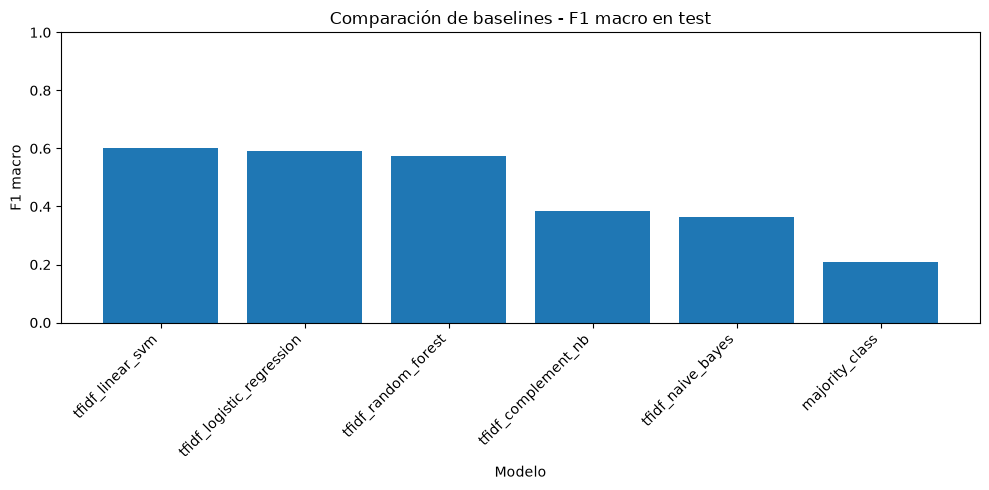

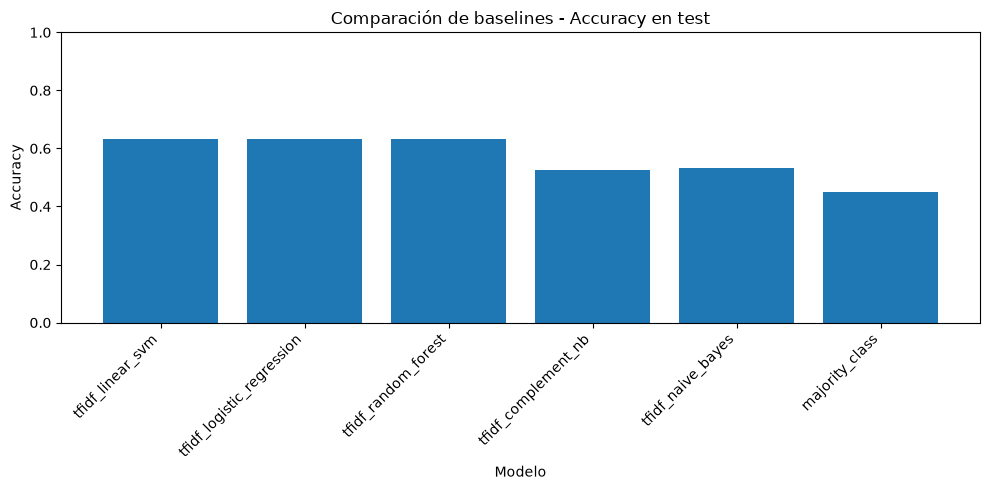

In [7]:

# ============================================================
# 7. Visualización de modelos baseline
# ============================================================

baseline_test = baseline_results[baseline_results["modelo"].str.endswith("_test")].copy()
baseline_test["modelo_limpio"] = baseline_test["modelo"].str.replace("_test", "", regex=False)
baseline_test = baseline_test.sort_values("f1_macro", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(baseline_test["modelo_limpio"], baseline_test["f1_macro"])
plt.title("Comparación de baselines - F1 macro en test")
plt.xlabel("Modelo")
plt.ylabel("F1 macro")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(VIS_DIR / "comparacion_baselines_f1_macro.png", dpi=180)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(baseline_test["modelo_limpio"], baseline_test["accuracy"])
plt.title("Comparación de baselines - Accuracy en test")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(VIS_DIR / "comparacion_baselines_accuracy.png", dpi=180)
plt.show()


In [8]:
# ============================================================
# 8. Tokenizador y Dataset PyTorch
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ABSADataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_len=160):
        self.texts = list(texts)
        self.labels = None if labels is None else list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
        }
        if self.labels is not None:
            item["labels"] = torch.tensor(LABEL_TO_ID[self.labels[idx]], dtype=torch.long)
        return item

train_dataset = ABSADataset(train_df["input_modelo"], train_df["label"], tokenizer, MAX_LEN)
validation_dataset = ABSADataset(validation_df["input_modelo"], validation_df["label"], tokenizer, MAX_LEN)
test_dataset = ABSADataset(test_df["input_modelo"], test_df["label"], tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Batches train:", len(train_loader))
print("Batches validation:", len(validation_loader))
print("Batches test:", len(test_loader))

Batches train: 478
Batches validation: 111
Batches test: 106


In [9]:
# ============================================================
# 9. Modelo BERT multilingual + TextCNN
# ============================================================

class BERTTextCNN(nn.Module):
    def __init__(self, model_name, num_labels, num_filters=128, kernel_sizes=(2, 3, 4), dropout=0.30):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=hidden_size, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(num_filters * len(kernel_sizes), num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state              # [B, L, H]
        x = sequence_output.transpose(1, 2)                      # [B, H, L]
        conv_outputs = []
        for conv in self.convs:
            c = torch.relu(conv(x))                              # [B, F, L-k+1]
            p = torch.max(c, dim=2).values                       # [B, F]
            conv_outputs.append(p)
        x = torch.cat(conv_outputs, dim=1)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits

model = BERTTextCNN(
    model_name=MODEL_NAME,
    num_labels=len(VALID_LABELS),
    num_filters=CNN_NUM_FILTERS,
    kernel_sizes=CNN_KERNEL_SIZES,
    dropout=DROPOUT,
).to(DEVICE)

print(model.__class__.__name__)
print("Número de labels:", len(VALID_LABELS))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTTextCNN
Número de labels: 3


In [10]:
# ============================================================
# 10. Entrenamiento con class weights y early stopping
# ============================================================

def compute_class_weights(labels):
    counts = pd.Series(labels).value_counts().reindex(VALID_LABELS, fill_value=0)
    total = counts.sum()
    weights = []
    for label in VALID_LABELS:
        count = counts[label]
        if count == 0:
            weights.append(0.0)
        else:
            w = total / (len(VALID_LABELS) * count)
            weights.append(w)
    return torch.tensor(weights, dtype=torch.float).to(DEVICE)

class_weights = compute_class_weights(train_df["label"])
print("Class weights:", {label: round(float(class_weights[i]), 4) for i, label in ID_TO_LABEL.items()})

class FocalLoss(nn.Module):
    """Focal Loss multiclase con class weights (alpha). gamma enfoca casos dificiles."""
    def __init__(self, weight=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, logits, target):
        ce = nn.functional.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

loss_fn = FocalLoss(weight=class_weights, gamma=FOCAL_GAMMA)
print(f"Loss: FocalLoss(gamma={FOCAL_GAMMA}) con class weights")
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)


def run_epoch(model, loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    split_name = "train" if train_mode else "val"
    for batch in tqdm(loader, desc=split_name, leave=False, unit="batch"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(logits, labels)

            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy().tolist()
        label_ids = labels.detach().cpu().numpy().tolist()
        all_preds.extend([ID_TO_LABEL[p] for p in preds])
        all_labels.extend([ID_TO_LABEL[y] for y in label_ids])

    avg_loss = total_loss / max(len(loader), 1)
    metrics = evaluate_predictions(all_labels, all_preds, prefix="bert_textcnn")
    metrics["loss"] = round(avg_loss, 6)
    return metrics, all_labels, all_preds

best_val_f1 = -1
best_state = None
patience_counter = 0
history = []

epoch_bar = tqdm(range(1, EPOCHS + 1), desc="Entrenamiento", unit="epoch")
for epoch in epoch_bar:
    train_metrics, _, _ = run_epoch(model, train_loader, train_mode=True)
    val_metrics, _, _ = run_epoch(model, validation_loader, train_mode=False)

    row = {"epoch": epoch}
    row.update({f"train_{k}": v for k, v in train_metrics.items() if k != "modelo"})
    row.update({f"validation_{k}": v for k, v in val_metrics.items() if k != "modelo"})
    history.append(row)

    epoch_bar.set_postfix({
        "tr_f1":  f"{train_metrics['f1_macro']:.3f}",
        "vl_f1":  f"{val_metrics['f1_macro']:.3f}",
        "vl_loss":f"{val_metrics['loss']:.4f}",
    })
    print(f"  Epoch {epoch}/{EPOCHS}  train_f1={train_metrics['f1_macro']:.4f}  val_f1={val_metrics['f1_macro']:.4f}  val_loss={val_metrics['loss']:.4f}")

    val_f1 = val_metrics["f1_macro"]
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print("Nuevo mejor modelo guardado en memoria.")
    else:
        patience_counter += 1
        print(f"Sin mejora. Paciencia {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping activado.")
            break

history_df = pd.DataFrame(history)
history_df.to_csv(REPORTS_DIR / "historial_entrenamiento_bert_textcnn.csv", index=False, encoding="utf-8-sig")

if best_state is not None:
    model.load_state_dict(best_state)

print("Mejor F1 macro validation:", best_val_f1)
display(history_df)

Class weights: {'negativo': 1.6511, 'neutro': 0.9304, 'positivo': 0.7578}
Loss: FocalLoss(gamma=0.0) con class weights


Entrenamiento:   0%|          | 0/10 [00:00<?, ?epoch/s]

train:   0%|          | 0/478 [00:00<?, ?batch/s]

val:   0%|          | 0/111 [00:00<?, ?batch/s]

  Epoch 1/10  train_f1=0.4006  val_f1=0.4520  val_loss=0.9638
Nuevo mejor modelo guardado en memoria.


...

  Epoch 9/10  train_f1=0.8627  val_f1=0.6796  val_loss=1.1066
Nuevo mejor modelo guardado en memoria.


train:   0%|          | 0/478 [00:00<?, ?batch/s]

val:   0%|          | 0/111 [00:00<?, ?batch/s]

  Epoch 10/10  train_f1=0.8835  val_f1=0.6700  val_loss=1.1807
Sin mejora. Paciencia 1/2
Mejor F1 macro validation: 0.6796


,epoch,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_precision_weighted,train_recall_weighted,train_f1_weighted,train_loss,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,validation_precision_weighted,validation_recall_weighted,validation_f1_weighted,validation_loss
0,1,0.4467,0.4021,0.4015,0.4006,0.4358,0.4467,0.4401,1.097671,0.6275,0.4414,0.5044,0.4520,0.5599,0.6275,0.5680,0.963774
1,2,0.5863,0.5451,0.5394,0.5376,0.5857,0.5863,0.5816,0.969697,0.6117,0.5263,0.5175,0.5132,0.5874,0.6117,0.5945,0.947156
2,3,0.6417,0.6122,0.6073,0.6084,0.6439,0.6417,0.6415,0.872723,0.6117,0.6035,0.6227,0.5915,0.6719,0.6117,0.6267,0.868662
3,4,0.6919,0.6709,0.6838,0.6748,0.7003,0.6919,0.6943,0.757786,0.6456,0.5886,0.5844,0.5843,0.6399,0.6456,0.6402,0.912876
4,5,0.7416,0.7225,0.7367,0.7276,0.7486,0.7416,0.7437,0.668076,0.6637,0.6393,0.6694,0.6390,0.7001,0.6637,0.6724,0.872383
5,6,0.7741,0.7543,0.7670,0.7592,0.7796,0.7741,0.7758,0.616366,0.6388,0.6153,0.6557,0.6146,0.6639,0.6388,0.6361,0.927394
6,7,0.8201,0.8031,0.8118,0.8069,0.8221,0.8201,0.8207,0.541451,0.6772,0.6475,0.6760,0.6516,0.6931,0.6772,0.6778,1.009447
7,8,0.8468,0.8332,0.8405,0.8365,0.8477,0.8468,0.8470,0.494047,0.6885,0.6601,0.6801,0.6665,0.6938,0.6885,0.6884,1.087000
8,9,0.8713,0.8597,0.8663,0.8627,0.8721,0.8713,0.8716,0.438094,0.7065,0.6756,0.6845,0.6796,0.7096,0.7065,0.7078,1.106571
9,10,0.8902,0.8809,0.8865,0.8835,0.8908,0.8902,0.8904,0.388411,0.6998,0.6697,0.6705,0.6700,0.7016,0.6998,0.7005,1.180748


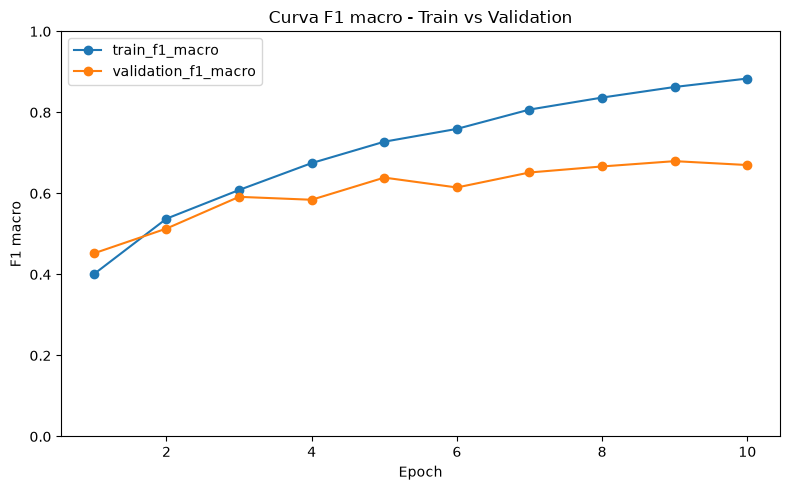

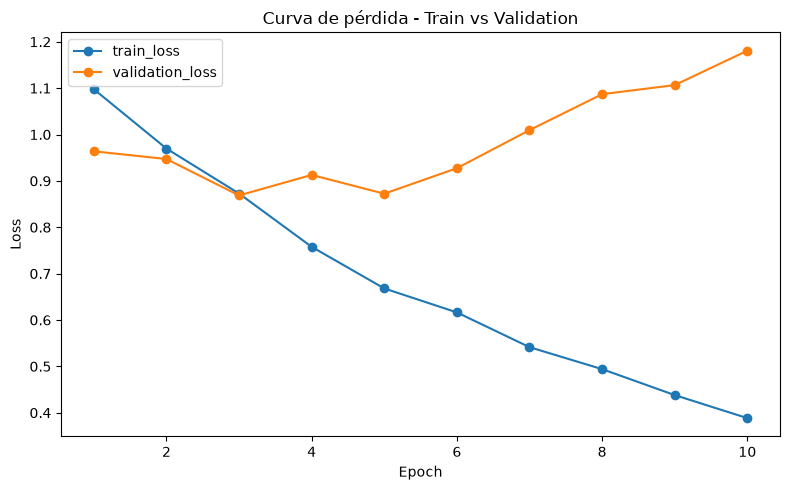

In [11]:

# ============================================================
# 11. Curvas de entrenamiento y validación
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_f1_macro"], marker="o", label="train_f1_macro")
plt.plot(history_df["epoch"], history_df["validation_f1_macro"], marker="o", label="validation_f1_macro")
plt.title("Curva F1 macro - Train vs Validation")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "curva_f1_macro_train_validation.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["validation_loss"], marker="o", label="validation_loss")
plt.title("Curva de pérdida - Train vs Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "curva_loss_train_validation.png", dpi=180)
plt.show()


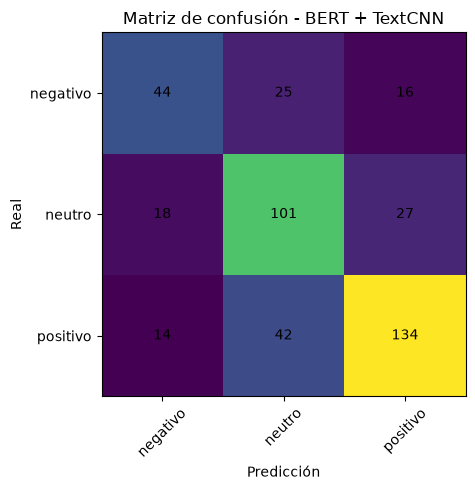

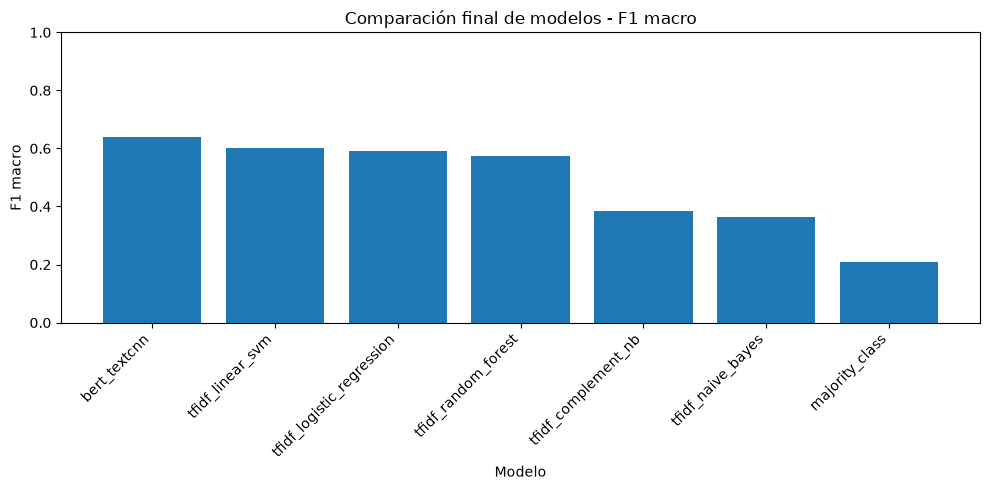

Resultados BERT + TextCNN


,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,loss
0,bert_textcnn_test,0.6627,0.6457,0.6382,0.64,0.667,0.6627,0.663,1.469026


Reporte de clasificación


,precision,recall,f1-score,support
negativo,0.578947,0.517647,0.546584,85.000000
neutro,0.601190,0.691781,0.643312,146.000000
positivo,0.757062,0.705263,0.730245,190.000000
accuracy,0.662708,0.662708,0.662708,0.662708
macro avg,0.645733,0.638230,0.640047,421.000000
weighted avg,0.667045,0.662708,0.663016,421.000000


Comparación de modelos


,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
6,bert_textcnn,0.6627,0.6457,0.6382,0.6400,0.6670,0.6627,0.6630
0,tfidf_linear_svm,0.6342,0.6064,0.6004,0.6007,0.6360,0.6342,0.6326
1,tfidf_logistic_regression,0.6318,0.5962,0.5932,0.5917,0.6354,0.6318,0.6305
2,tfidf_random_forest,0.6318,0.6033,0.5721,0.5750,0.6216,0.6318,0.6182
3,tfidf_complement_nb,0.5273,0.6764,0.4276,0.3831,0.6164,0.5273,0.4635
4,tfidf_naive_bayes,0.5321,0.3496,0.4199,0.3639,0.4201,0.5321,0.4494
5,majority_class,0.4513,0.1504,0.3333,0.2073,0.2037,0.4513,0.2807


In [12]:

# ============================================================
# 12. Evaluación final en test, matriz de confusión y comparación
# ============================================================

def predict_loader_with_probs(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    all_probs = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            total_loss += loss.item()
            all_true.extend([ID_TO_LABEL[int(x)] for x in labels.detach().cpu().numpy()])
            all_pred.extend([ID_TO_LABEL[int(x)] for x in preds.detach().cpu().numpy()])
            all_probs.extend(probs.detach().cpu().numpy().tolist())

    metrics = evaluate_predictions(all_true, all_pred, prefix="bert_textcnn_test")
    metrics["loss"] = round(total_loss / max(len(loader), 1), 6)
    return metrics, all_true, all_pred, np.array(all_probs)


test_metrics, y_true_test, y_pred_test, y_probs_test = predict_loader_with_probs(model, test_loader)
bert_results = pd.DataFrame([test_metrics])
bert_results.to_csv(REPORTS_DIR / "resultados_bert_textcnn.csv", index=False, encoding="utf-8-sig")

test_predictions = test_df.copy().reset_index(drop=True)
test_predictions["label_real"] = y_true_test
test_predictions["label_predicho"] = y_pred_test
test_predictions["pred_correcto"] = test_predictions["label_real"] == test_predictions["label_predicho"]
for idx, label in ID_TO_LABEL.items():
    test_predictions[f"prob_{label}"] = y_probs_test[:, idx]
test_predictions.to_csv(PREDICTIONS_DIR / "predicciones_test_bert_textcnn.csv", index=False, encoding="utf-8-sig")

report_dict = classification_report(
    y_true_test,
    y_pred_test,
    labels=VALID_LABELS,
    output_dict=True,
    zero_division=0,
)
classification_report_df = pd.DataFrame(report_dict).transpose()
classification_report_df.to_csv(REPORTS_DIR / "classification_report_bert_textcnn.csv", encoding="utf-8-sig")

cm = confusion_matrix(y_true_test, y_pred_test, labels=VALID_LABELS)
cm_df = pd.DataFrame(cm, index=[f"real_{l}" for l in VALID_LABELS], columns=[f"pred_{l}" for l in VALID_LABELS])
cm_df.to_csv(REPORTS_DIR / "matriz_confusion_bert_textcnn.csv", encoding="utf-8-sig")

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Matriz de confusión - BERT + TextCNN")
plt.xticks(range(len(VALID_LABELS)), VALID_LABELS, rotation=45)
plt.yticks(range(len(VALID_LABELS)), VALID_LABELS)
plt.xlabel("Predicción")
plt.ylabel("Real")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(VIS_DIR / "matriz_confusion_bert_textcnn.png", dpi=180)
plt.show()

# Comparación final de modelos solo con test
baseline_test_for_comparison = baseline_test[["modelo_limpio", "accuracy", "precision_macro", "recall_macro", "f1_macro", "precision_weighted", "recall_weighted", "f1_weighted"]].copy()
baseline_test_for_comparison = baseline_test_for_comparison.rename(columns={"modelo_limpio": "modelo"})
bert_for_comparison = bert_results.copy().rename(columns={"modelo": "modelo_original"})
bert_for_comparison["modelo"] = "bert_textcnn"
bert_for_comparison = bert_for_comparison[["modelo", "accuracy", "precision_macro", "recall_macro", "f1_macro", "precision_weighted", "recall_weighted", "f1_weighted"]]

comparison = pd.concat([baseline_test_for_comparison, bert_for_comparison], ignore_index=True, sort=False)
comparison = comparison.sort_values("f1_macro", ascending=False)
comparison.to_csv(REPORTS_DIR / "comparacion_modelos.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(10, 5))
plt.bar(comparison["modelo"], comparison["f1_macro"])
plt.title("Comparación final de modelos - F1 macro")
plt.xlabel("Modelo")
plt.ylabel("F1 macro")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(VIS_DIR / "comparacion_modelos_f1_macro.png", dpi=180)
plt.show()

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "label_to_id": LABEL_TO_ID,
    "id_to_label": ID_TO_LABEL,
    "max_len": MAX_LEN,
    "valid_aspects": VALID_ASPECTS,
    "cnn_num_filters": CNN_NUM_FILTERS,
    "cnn_kernel_sizes": CNN_KERNEL_SIZES,
    "dropout": DROPOUT,
}
torch.save(checkpoint, MODELS_DIR / "modelo_bert_textcnn_multilingual.pt")
tokenizer.save_pretrained(MODELS_DIR / "tokenizer_bert_multilingual")

with open(MODELS_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"label_to_id": LABEL_TO_ID, "id_to_label": ID_TO_LABEL}, f, ensure_ascii=False, indent=2)

print("Resultados BERT + TextCNN")
display(bert_results)
print("Reporte de clasificación")
display(classification_report_df)
print("Comparación de modelos")
display(comparison)


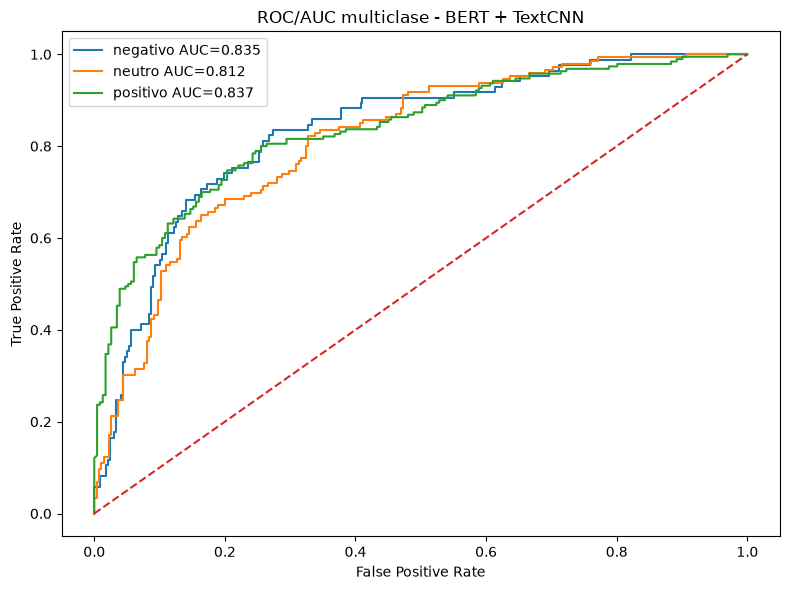

,modelo,clase,auc
0,bert_textcnn,negativo,0.834699
1,bert_textcnn,neutro,0.812478
2,bert_textcnn,positivo,0.837081


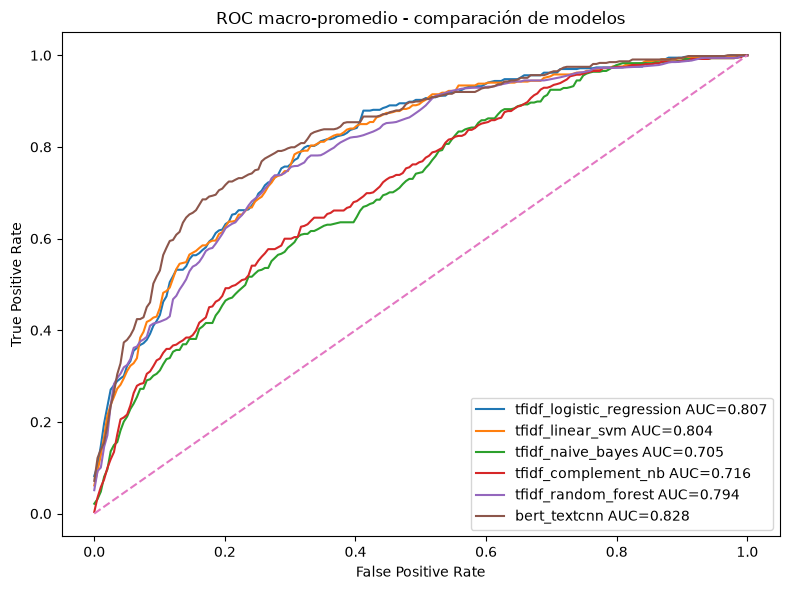

In [13]:

# ============================================================
# 13. Curvas ROC / AUC multiclase
# ============================================================

classes = VALID_LABELS
y_test_bin = label_binarize(y_true_test, classes=classes)

# ROC por clase para BERT
plt.figure(figsize=(8, 6))
auc_rows = []
for i, label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    auc_rows.append({"modelo": "bert_textcnn", "clase": label, "auc": roc_auc})
    plt.plot(fpr, tpr, label=f"{label} AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC/AUC multiclase - BERT + TextCNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "roc_auc_multiclase_bert_textcnn.png", dpi=180)
plt.show()

auc_df = pd.DataFrame(auc_rows)
auc_df.to_csv(REPORTS_DIR / "auc_por_clase_bert_textcnn.csv", index=False, encoding="utf-8-sig")
display(auc_df)

# ROC macro-promedio comparando modelos con scores disponibles
plt.figure(figsize=(8, 6))
mean_fpr = np.linspace(0, 1, 200)

for model_name, scores in baseline_scores_for_roc.items():
    tprs = []
    for i in range(len(classes)):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], scores[:, i])
        tprs.append(np.interp(mean_fpr, fpr_i, tpr_i))
    mean_tpr = np.mean(tprs, axis=0)
    macro_auc = auc(mean_fpr, mean_tpr)
    plt.plot(mean_fpr, mean_tpr, label=f"{model_name} AUC={macro_auc:.3f}")

bert_tprs = []
for i in range(len(classes)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_probs_test[:, i])
    bert_tprs.append(np.interp(mean_fpr, fpr_i, tpr_i))
bert_mean_tpr = np.mean(bert_tprs, axis=0)
bert_macro_auc = auc(mean_fpr, bert_mean_tpr)
plt.plot(mean_fpr, bert_mean_tpr, label=f"bert_textcnn AUC={bert_macro_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC macro-promedio - comparación de modelos")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "roc_macro_comparacion_modelos.png", dpi=180)
plt.show()


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,aspecto,soporte
4,0.8227,0.8128,0.5240,0.5489,0.8267,0.8227,0.8005,atractivos,141
9,0.5385,0.6667,0.5278,0.5333,0.6154,0.5385,0.5308,seguridad,13
0,0.6111,0.5833,0.4986,0.5191,0.5995,0.6111,0.5873,accesibilidad,54
7,0.6923,0.5333,0.5000,0.4722,0.7385,0.6923,0.6538,gastronomia,13
5,0.6190,0.4209,0.5238,0.4667,0.4988,0.6190,0.5524,clima,21
6,0.5167,0.4810,0.4440,0.4519,0.5057,0.5167,0.5044,costos,60
8,0.4706,0.5833,0.4643,0.3944,0.6765,0.4706,0.4245,limpieza,17
1,0.5926,0.3730,0.3958,0.3771,0.5150,0.5926,0.5434,aforo_multitudes,27
3,0.6154,0.4048,0.3816,0.3686,0.5374,0.6154,0.5521,atencion_servicio,65
2,0.6000,0.5185,0.4000,0.3492,0.7778,0.6000,0.5238,alojamiento,10


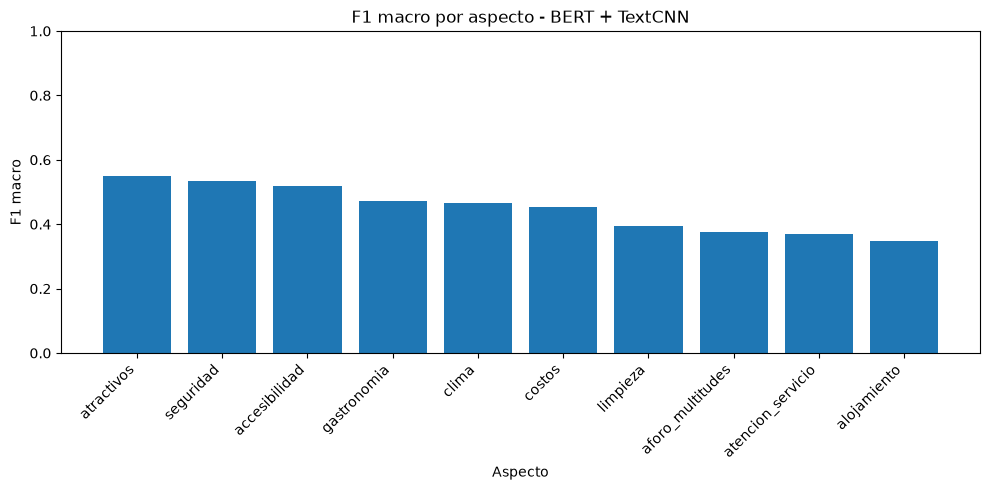

In [14]:

# ============================================================
# 14. Análisis por aspecto en test
# ============================================================

aspect_rows = []
for aspect, group in test_predictions.groupby("aspecto"):
    if len(group) < 5:
        continue
    metrics = evaluate_predictions(group["label_real"], group["label_predicho"], prefix=aspect)
    metrics["aspecto"] = aspect
    metrics["soporte"] = len(group)
    aspect_rows.append(metrics)

aspect_analysis = pd.DataFrame(aspect_rows)
if not aspect_analysis.empty:
    aspect_analysis = aspect_analysis.drop(columns=["modelo"]).sort_values("f1_macro", ascending=False)
    aspect_analysis.to_csv(REPORTS_DIR / "analisis_por_aspecto_bert_textcnn.csv", index=False, encoding="utf-8-sig")
    display(aspect_analysis)

    plt.figure(figsize=(10, 5))
    plt.bar(aspect_analysis["aspecto"], aspect_analysis["f1_macro"])
    plt.title("F1 macro por aspecto - BERT + TextCNN")
    plt.xlabel("Aspecto")
    plt.ylabel("F1 macro")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(VIS_DIR / "f1_macro_por_aspecto_bert_textcnn.png", dpi=180)
    plt.show()
else:
    print("No hay soporte suficiente para análisis por aspecto.")


,cantidad,count
0,positivo_como_neutro,42
1,neutro_como_positivo,27
2,negativo_como_neutro,25
3,neutro_como_negativo,18
4,negativo_como_positivo,16
5,positivo_como_negativo,14


,review_uid,destination,aspecto,text_clean,label_real,label_predicho,tipo_error
7,gm_8c29b6c50f320caf,Santuario Histórico de Machu Picchu,atractivos,This is my third time here and let me tell you...,positivo,negativo,positivo_como_negativo
15,gm_f572915228183cbf,Santuario Histórico de Machu Picchu,costos,Great view but to touristic. People who are wo...,neutro,positivo,neutro_como_positivo
18,gm_f572915228183cbf,Santuario Histórico de Machu Picchu,aforo_multitudes,Great view but to touristic. People who are wo...,neutro,negativo,neutro_como_negativo
23,gm_da468ddeeca0eee0,Líneas y Geoglifos de Nasca y Palpa,accesibilidad,"Something I'd wanted to do since a kid, and so...",negativo,neutro,negativo_como_neutro
25,gm_fcb8d5ec3b50e306,Reserva Nacional de Paracas,limpieza,It’s a like a bay from Mediterranean. Really g...,negativo,positivo,negativo_como_positivo
28,gm_c31b3fcc96339036,Centro Histórico de Lima,atencion_servicio,Square was barricaded and no one was allowed i...,negativo,neutro,negativo_como_neutro
29,gm_17cd1255a94fec6b,Ciudadela de Kuélap,costos,Very Disappointed nobody told us even on the w...,neutro,negativo,neutro_como_negativo
31,gm_17cd1255a94fec6b,Ciudadela de Kuélap,accesibilidad,Very Disappointed nobody told us even on the w...,negativo,neutro,negativo_como_neutro
35,gm_8218ccc8edc88170,Monasterio de Santa Catalina,atractivos,Interesante para visitar 😉 y aprender un poco ...,neutro,positivo,neutro_como_positivo
38,gm_8e5dc68d1ac17316,Centro Histórico de Lima,costos,"Nuestra bella Plaza de Lima, aquí vienen mucho...",neutro,positivo,neutro_como_positivo


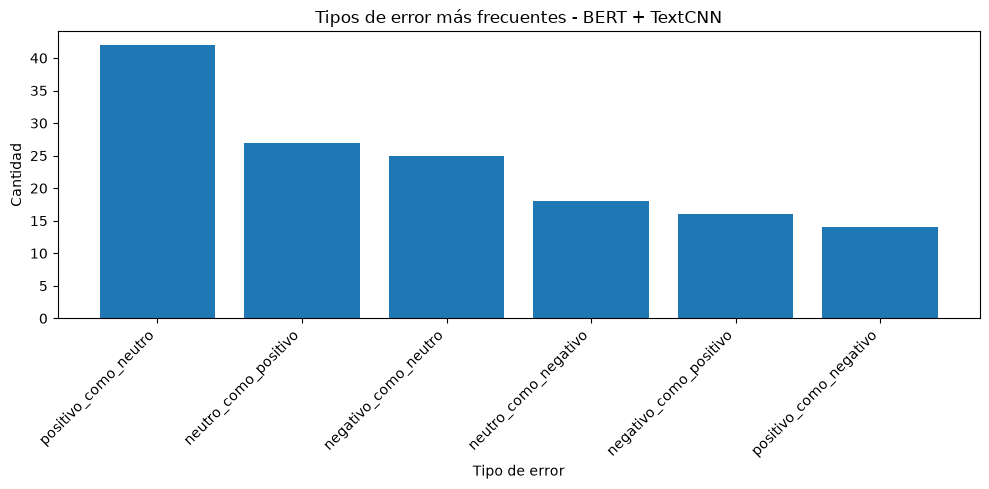

In [15]:

# ============================================================
# 15. Análisis de errores del modelo
# ============================================================

errors_df = test_predictions[test_predictions["pred_correcto"] == False].copy()
errors_df["tipo_error"] = errors_df["label_real"] + "_como_" + errors_df["label_predicho"]
errors_df.to_csv(REPORTS_DIR / "errores_test_bert_textcnn.csv", index=False, encoding="utf-8-sig")

error_counts = errors_df["tipo_error"].value_counts()
error_counts.to_csv(REPORTS_DIR / "conteo_tipos_error_bert_textcnn.csv", encoding="utf-8-sig")

display(error_counts.reset_index().rename(columns={"index": "tipo_error", "tipo_error": "cantidad"}))
display(errors_df[["review_uid", "destination", "aspecto", "text_clean", "label_real", "label_predicho", "tipo_error"]].head(20))

plt.figure(figsize=(10, 5))
plt.bar(error_counts.index.astype(str), error_counts.values)
plt.title("Tipos de error más frecuentes - BERT + TextCNN")
plt.xlabel("Tipo de error")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(VIS_DIR / "tipos_error_bert_textcnn.png", dpi=180)
plt.show()


In [16]:
# ============================================================
# 10. Diccionario de aspectos para inferencia sobre corpus completo
# ============================================================

ASPECT_KEYWORDS = {
    "atractivos": [
        "vista", "vistas", "paisaje", "paisajes", "hermoso", "hermosa", "bonito", "bonita",
        "bello", "bella", "increible", "maravilloso", "maravillosa", "ruinas", "arqueologico",
        "arqueologica", "cultura", "historia", "historico", "monumento", "patrimonio", "museo",
        "beautiful", "view", "views", "landscape", "amazing", "wonderful", "historic", "history", "culture",
    ],
    "costos": [
        "precio", "precios", "costo", "costos", "caro", "cara", "barato", "barata", "entrada",
        "boleto", "ticket", "tarifa", "pagar", "cobran", "cost", "price", "expensive", "cheap", "fee", "entrance",
    ],
    "seguridad": [
        "seguro", "segura", "seguridad", "inseguro", "peligro", "peligroso", "riesgo", "robo",
        "policia", "vigilancia", "safe", "safety", "danger", "dangerous", "risk", "police", "security",
    ],
    "accesibilidad": [
        "acceso", "accesible", "camino", "ruta", "carretera", "transporte", "bus", "taxi",
        "subida", "bajada", "escaleras", "llegar", "entrada", "access", "road", "route", "transport", "walk", "stairs",
    ],
    "limpieza": [
        "limpio", "limpia", "limpieza", "sucio", "sucia", "basura", "residuos", "baño", "baños",
        "clean", "dirty", "trash", "garbage", "bathroom", "toilet", "restroom",
    ],
    "atencion_servicio": [
        "atencion", "servicio", "personal", "guia", "guias", "trato", "boleteria", "informacion",
        "organizacion", "amable", "amables", "staff", "service", "guide", "guides", "attention", "friendly", "information",
    ],
    "gastronomia": [
        "comida", "restaurante", "restaurantes", "plato", "platos", "gastronomia", "almuerzo", "cena",
        "food", "restaurant", "restaurants", "dish", "meal", "lunch", "dinner",
    ],
    "alojamiento": [
        "hotel", "hostal", "hospedaje", "alojamiento", "habitacion", "dormir", "estadía", "estadia",
        "hotel", "hostel", "lodging", "room", "stay", "accommodation",
    ],
    "clima": [
        "clima", "lluvia", "llueve", "frio", "fría", "fria", "calor", "sol", "nublado", "viento",
        "weather", "rain", "cold", "hot", "sun", "cloudy", "wind",
    ],
    "aforo_multitudes": [
        "gente", "multitud", "multitudes", "lleno", "llena", "cola", "colas", "fila", "filas",
        "aglomerado", "congestion", "crowded", "crowd", "people", "queue", "line", "packed", "full of people",
    ],
}


def normalize_for_detection(text):
    text = "" if pd.isna(text) else str(text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9ñ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def detect_aspects(text):
    normalized = normalize_for_detection(text)
    found = []
    for aspect, keywords in ASPECT_KEYWORDS.items():
        for kw in keywords:
            kw_norm = normalize_for_detection(kw)
            if not kw_norm:
                continue
            if re.search(r"(?<!\w)" + re.escape(kw_norm) + r"(?!\w)", normalized):
                found.append(aspect)
                break
    return found

print("Diccionario de aspectos cargado:", len(ASPECT_KEYWORDS))

Diccionario de aspectos cargado: 10


In [17]:
# ============================================================
# 11. Preparación del corpus completo para inferencia ABSA
# ============================================================

FULL_REVIEWS_FILE = find_file("tourism_reviews_clean.csv", preferred_dirs=[DATA_DIR, BASE_DIR, Path("/mnt/data")])
print("Corpus completo Fase 1:", FULL_REVIEWS_FILE)

reviews = pd.read_csv(FULL_REVIEWS_FILE, encoding="utf-8-sig")
required_review_cols = ["review_uid", "destination", "text_clean"]
missing = [c for c in required_review_cols if c not in reviews.columns]
if missing:
    raise ValueError(f"tourism_reviews_clean.csv no tiene columnas obligatorias: {missing}")

reviews = reviews.dropna(subset=["review_uid", "destination", "text_clean"]).copy()
reviews["text_clean"] = reviews["text_clean"].astype(str)

absa_rows = []
for _, row in reviews.iterrows():
    aspects = detect_aspects(row["text_clean"])
    for aspect in aspects:
        absa_rows.append({
            "review_uid": row["review_uid"],
            "destination": row["destination"],
            "language_review": row.get("language_review", ""),
            "aspecto": aspect,
            "text_clean": row["text_clean"],
            "input_modelo": f"aspecto: {aspect} reseña: {row['text_clean']}",
        })

absa_ready = pd.DataFrame(absa_rows)
if not USE_ASPECT_TOKEN and not absa_ready.empty:
    absa_ready["input_modelo"] = absa_ready["text_clean"].astype(str)
absa_ready.to_csv(PREDICTIONS_DIR / "tourism_reviews_clean_absa_ready.csv", index=False, encoding="utf-8-sig")

print("Reseñas originales:", len(reviews))
print("Tuplas aspecto-reseña para inferencia:", len(absa_ready))
print("Reseñas con al menos un aspecto detectado:", absa_ready["review_uid"].nunique() if not absa_ready.empty else 0)

display(absa_ready.head())

Corpus completo Fase 1: d:\Tesis\ABSA_Turismo_Fase2_V3\data\tourism_reviews_clean.csv
Reseñas originales: 12657
Tuplas aspecto-reseña para inferencia: 21040
Reseñas con al menos un aspecto detectado: 10696


,review_uid,destination,language_review,aspecto,text_clean,input_modelo
0,gm_0167bcd0fb09f2c1,Centro Histórico de Lima,en,atractivos,Pretty good spot to people watch. Architecture...,aspecto: atractivos reseña: Pretty good spot t...
1,gm_0167bcd0fb09f2c1,Centro Histórico de Lima,en,aforo_multitudes,Pretty good spot to people watch. Architecture...,aspecto: aforo_multitudes reseña: Pretty good ...
2,gm_0183856b513ebd59,Centro Histórico de Lima,en,atractivos,Beautiful plaza. Perfect for people watching. ...,aspecto: atractivos reseña: Beautiful plaza. P...
3,gm_0183856b513ebd59,Centro Histórico de Lima,en,aforo_multitudes,Beautiful plaza. Perfect for people watching. ...,aspecto: aforo_multitudes reseña: Beautiful pl...
4,gm_01aaf3f252b206b5,Centro Histórico de Lima,en,atractivos,A beautiful and well maintained plaza in the h...,aspecto: atractivos reseña: A beautiful and we...


In [18]:
# ============================================================
# 12. Inferencia del modelo sobre el corpus completo
# ============================================================

class ABSAInferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=160):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
        }


def predict_dataframe(df, batch_size=16):
    if df.empty:
        return df.copy()
    dataset = ABSAInferenceDataset(df["input_modelo"].astype(str).tolist(), tokenizer, MAX_LEN)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    pred_labels = []
    confidences = []
    prob_rows = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(logits, dim=1)
            conf, preds = torch.max(probs, dim=1)
            pred_labels.extend([ID_TO_LABEL[int(p)] for p in preds.cpu().numpy()])
            confidences.extend(conf.cpu().numpy().tolist())
            prob_rows.extend(probs.cpu().numpy().tolist())

    out = df.copy()
    out["label_predicho"] = pred_labels
    out["score_sentimiento"] = out["label_predicho"].map(SCORE_BY_LABEL)
    out["confianza"] = confidences
    for idx, label in ID_TO_LABEL.items():
        out[f"prob_{label}"] = [row[idx] for row in prob_rows]
    return out

predicciones_absa = predict_dataframe(absa_ready, batch_size=max(BATCH_SIZE, 16))
predicciones_absa.to_csv(PREDICTIONS_DIR / "predicciones_absa.csv", index=False, encoding="utf-8-sig")

# En esta tesis, tuplas_absa.csv es la salida lista para agregación por destino/aspecto.
tuplas_absa = predicciones_absa.copy()
tuplas_absa.to_csv(PREDICTIONS_DIR / "tuplas_absa.csv", index=False, encoding="utf-8-sig")

print("Predicciones ABSA guardadas:", predicciones_absa.shape)
display(predicciones_absa.head())

Predicciones ABSA guardadas: (21040, 12)


,review_uid,destination,language_review,aspecto,text_clean,input_modelo,label_predicho,score_sentimiento,confianza,prob_negativo,prob_neutro,prob_positivo
0,gm_0167bcd0fb09f2c1,Centro Histórico de Lima,en,atractivos,Pretty good spot to people watch. Architecture...,aspecto: atractivos reseña: Pretty good spot t...,positivo,1,0.997501,0.000999,0.001500,0.997501
1,gm_0167bcd0fb09f2c1,Centro Histórico de Lima,en,aforo_multitudes,Pretty good spot to people watch. Architecture...,aspecto: aforo_multitudes reseña: Pretty good ...,neutro,0,0.650408,0.339506,0.650408,0.010086
2,gm_0183856b513ebd59,Centro Histórico de Lima,en,atractivos,Beautiful plaza. Perfect for people watching. ...,aspecto: atractivos reseña: Beautiful plaza. P...,positivo,1,0.997194,0.001045,0.001761,0.997194
3,gm_0183856b513ebd59,Centro Histórico de Lima,en,aforo_multitudes,Beautiful plaza. Perfect for people watching. ...,aspecto: aforo_multitudes reseña: Beautiful pl...,negativo,-1,0.881377,0.881377,0.112710,0.005913
4,gm_01aaf3f252b206b5,Centro Histórico de Lima,en,atractivos,A beautiful and well maintained plaza in the h...,aspecto: atractivos reseña: A beautiful and we...,positivo,1,0.997414,0.000920,0.001667,0.997414


In [19]:
# ============================================================
# 13. Matriz ABSA destino-aspecto
# ============================================================

if tuplas_absa.empty:
    raise ValueError("No hay tuplas ABSA. Revisa el diccionario de aspectos o el corpus de entrada.")

# Conteos por polaridad
polar_counts = (
    tuplas_absa
    .groupby(["destination", "aspecto", "label_predicho"])
    .size()
    .reset_index(name="cantidad")
)

polar_pivot = polar_counts.pivot_table(
    index=["destination", "aspecto"],
    columns="label_predicho",
    values="cantidad",
    fill_value=0,
).reset_index()

for label in VALID_LABELS:
    if label not in polar_pivot.columns:
        polar_pivot[label] = 0

polar_pivot["total_tuplas"] = polar_pivot[VALID_LABELS].sum(axis=1)
for label in VALID_LABELS:
    polar_pivot[f"pct_{label}"] = np.where(
        polar_pivot["total_tuplas"] > 0,
        polar_pivot[label] / polar_pivot["total_tuplas"],
        0,
    )

score_agg = (
    tuplas_absa
    .groupby(["destination", "aspecto"])
    .agg(
        score_promedio=("score_sentimiento", "mean"),
        confianza_promedio=("confianza", "mean"),
        reseñas_unicas=("review_uid", "nunique"),
    )
    .reset_index()
)

matriz_detallada = polar_pivot.merge(score_agg, on=["destination", "aspecto"], how="left")
matriz_detallada["score_normalizado_0_1"] = (matriz_detallada["score_promedio"] + 1) / 2
matriz_detallada = matriz_detallada.sort_values(["destination", "aspecto"]).reset_index(drop=True)

matriz_detallada.to_csv(MATRICES_DIR / "matriz_absa_detallada.csv", index=False, encoding="utf-8-sig")

matriz_normalizada = matriz_detallada.pivot_table(
    index="destination",
    columns="aspecto",
    values="score_normalizado_0_1",
    aggfunc="mean",
).reset_index()
matriz_normalizada.to_csv(MATRICES_DIR / "matriz_absa_normalizada.csv", index=False, encoding="utf-8-sig")

soporte = matriz_detallada[["destination", "aspecto", "total_tuplas", "reseñas_unicas", "confianza_promedio"]].copy()
soporte.to_csv(MATRICES_DIR / "soporte_destino_aspecto.csv", index=False, encoding="utf-8-sig")

# Diagnóstico simple para Fase 3: marca aspecto fuerte, débil o sin soporte suficiente.
def diagnostico(row):
    if row["total_tuplas"] < 10:
        return "soporte_bajo"
    if row["score_normalizado_0_1"] >= 0.70:
        return "percepcion_favorable"
    if row["score_normalizado_0_1"] <= 0.40:
        return "percepcion_desfavorable"
    return "percepcion_mixta"

matriz_detallada["diagnostico"] = matriz_detallada.apply(diagnostico, axis=1)
matriz_detallada[["destination", "aspecto", "score_normalizado_0_1", "total_tuplas", "diagnostico"]].to_csv(
    MATRICES_DIR / "diagnostico_aspectos_fase3.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Matriz detallada:", matriz_detallada.shape)
print("Matriz normalizada:", matriz_normalizada.shape)
display(matriz_detallada.head())
display(matriz_normalizada.head())

Matriz detallada: (100, 14)
Matriz normalizada: (10, 11)


,destination,aspecto,negativo,neutro,positivo,total_tuplas,pct_negativo,pct_neutro,pct_positivo,score_promedio,confianza_promedio,reseñas_unicas,score_normalizado_0_1,diagnostico
0,Centro Histórico de Lima,accesibilidad,11.0,106.0,29.0,146.0,0.075342,0.726027,0.198630,0.123288,0.934132,146,0.561644,percepcion_mixta
1,Centro Histórico de Lima,aforo_multitudes,138.0,60.0,16.0,214.0,0.644860,0.280374,0.074766,-0.570093,0.867357,214,0.214953,percepcion_desfavorable
2,Centro Histórico de Lima,alojamiento,0.0,11.0,7.0,18.0,0.000000,0.611111,0.388889,0.388889,0.894945,18,0.694444,percepcion_mixta
3,Centro Histórico de Lima,atencion_servicio,6.0,61.0,39.0,106.0,0.056604,0.575472,0.367925,0.311321,0.897013,106,0.655660,percepcion_mixta
4,Centro Histórico de Lima,atractivos,12.0,1.0,971.0,984.0,0.012195,0.001016,0.986789,0.974593,0.992845,984,0.987297,percepcion_favorable


aspecto,destination,accesibilidad,aforo_multitudes,alojamiento,atencion_servicio,atractivos,clima,costos,gastronomia,limpieza,seguridad
0,Centro Histórico de Lima,0.561644,0.214953,0.694444,0.655660,0.987297,0.196970,0.640845,0.641892,0.934389,0.793443
1,Circuito Mágico del Agua,0.557647,0.196226,0.785714,0.611538,0.991264,0.376812,0.681004,0.566489,0.873333,0.789216
2,Ciudadela de Kuélap,0.598446,0.181818,0.600000,0.583969,0.963303,0.245098,0.600000,0.521739,0.950000,0.833333
3,Líneas y Geoglifos de Nasca y Palpa,0.511905,0.234375,0.500000,0.551724,0.926573,0.166667,0.571429,0.666667,0.375000,0.772727
4,Monasterio de Santa Catalina,0.571809,0.208333,0.642857,0.615813,0.982092,0.472222,0.646974,0.600000,0.919355,1.000000


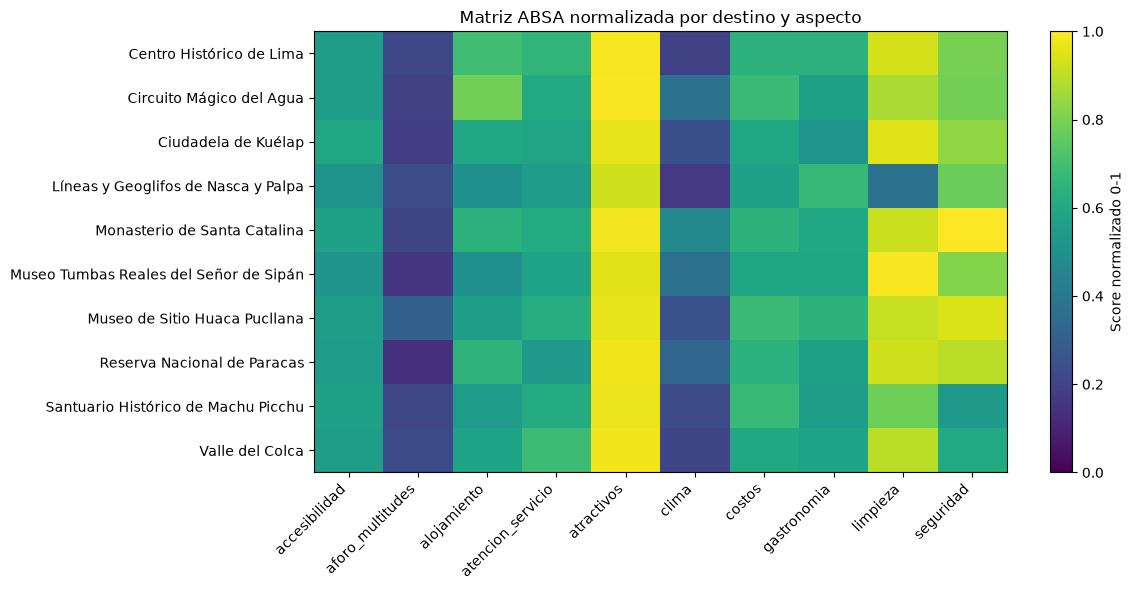

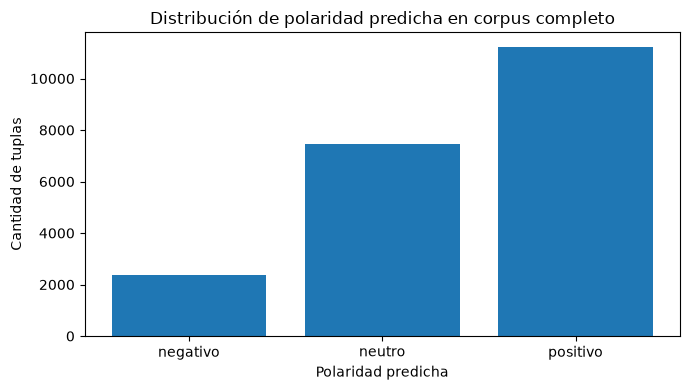

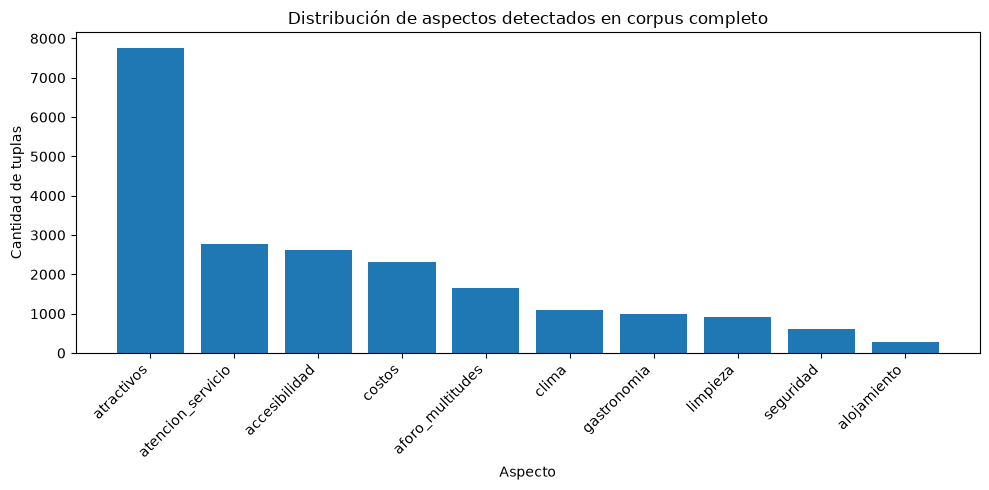

In [20]:

# ============================================================
# 19. Visualización de matriz ABSA y distribución de predicciones
# ============================================================

heatmap_df = matriz_normalizada.set_index("destination")
if not heatmap_df.empty:
    plt.figure(figsize=(12, 6))
    plt.imshow(heatmap_df.values, aspect="auto", vmin=0, vmax=1)
    plt.colorbar(label="Score normalizado 0-1")
    plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
    plt.title("Matriz ABSA normalizada por destino y aspecto")
    plt.tight_layout()
    plt.savefig(VIS_DIR / "matriz_absa_heatmap.png", dpi=180)
    plt.show()

pred_label_counts = tuplas_absa["label_predicho"].value_counts().reindex(VALID_LABELS).fillna(0)
plt.figure(figsize=(7, 4))
plt.bar(pred_label_counts.index, pred_label_counts.values)
plt.title("Distribución de polaridad predicha en corpus completo")
plt.xlabel("Polaridad predicha")
plt.ylabel("Cantidad de tuplas")
plt.tight_layout()
plt.savefig(VIS_DIR / "distribucion_polaridad_predicha_corpus_completo.png", dpi=180)
plt.show()

pred_aspect_counts = tuplas_absa["aspecto"].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(pred_aspect_counts.index, pred_aspect_counts.values)
plt.title("Distribución de aspectos detectados en corpus completo")
plt.xlabel("Aspecto")
plt.ylabel("Cantidad de tuplas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(VIS_DIR / "distribucion_aspectos_corpus_completo.png", dpi=180)
plt.show()


In [21]:
# ============================================================
# 14. Registro final de archivos generados
# ============================================================

outputs_generated = [
    REPORTS_DIR / "resumen_gold_set_y_splits.csv",
    REPORTS_DIR / "distribucion_aspecto_label_gold_set.csv",
    REPORTS_DIR / "distribucion_labels_por_split.csv",
    REPORTS_DIR / "auc_por_clase_bert_textcnn.csv",
    REPORTS_DIR / "analisis_por_aspecto_bert_textcnn.csv",
    REPORTS_DIR / "errores_test_bert_textcnn.csv",
    REPORTS_DIR / "conteo_tipos_error_bert_textcnn.csv",
    VIS_DIR / "distribucion_longitud_gold_set.png",
    VIS_DIR / "distribucion_labels_gold_set.png",
    VIS_DIR / "distribucion_aspectos_gold_set.png",
    VIS_DIR / "distribucion_destinos_gold_set.png",
    VIS_DIR / "distribucion_labels_por_split.png",
    VIS_DIR / "comparacion_baselines_f1_macro.png",
    VIS_DIR / "comparacion_baselines_accuracy.png",
    VIS_DIR / "curva_f1_macro_train_validation.png",
    VIS_DIR / "curva_loss_train_validation.png",
    VIS_DIR / "roc_auc_multiclase_bert_textcnn.png",
    VIS_DIR / "roc_macro_comparacion_modelos.png",
    VIS_DIR / "f1_macro_por_aspecto_bert_textcnn.png",
    VIS_DIR / "tipos_error_bert_textcnn.png",
    VIS_DIR / "matriz_absa_heatmap.png",
    VIS_DIR / "distribucion_polaridad_predicha_corpus_completo.png",
    VIS_DIR / "distribucion_aspectos_corpus_completo.png",
    REPORTS_DIR / "resultados_baselines_ml.csv",
    REPORTS_DIR / "historial_entrenamiento_bert_textcnn.csv",
    REPORTS_DIR / "resultados_bert_textcnn.csv",
    REPORTS_DIR / "classification_report_bert_textcnn.csv",
    REPORTS_DIR / "matriz_confusion_bert_textcnn.csv",
    REPORTS_DIR / "comparacion_modelos.csv",
    PREDICTIONS_DIR / "predicciones_baselines_test.csv",
    PREDICTIONS_DIR / "predicciones_test_bert_textcnn.csv",
    PREDICTIONS_DIR / "tourism_reviews_clean_absa_ready.csv",
    PREDICTIONS_DIR / "predicciones_absa.csv",
    PREDICTIONS_DIR / "tuplas_absa.csv",
    MATRICES_DIR / "matriz_absa_detallada.csv",
    MATRICES_DIR / "matriz_absa_normalizada.csv",
    MATRICES_DIR / "soporte_destino_aspecto.csv",
    MATRICES_DIR / "diagnostico_aspectos_fase3.csv",
    VIS_DIR / "matriz_confusion_bert_textcnn.png",
    MODELS_DIR / "modelo_bert_textcnn_multilingual.pt",
    MODELS_DIR / "label_mapping.json",
]

files_report = pd.DataFrame([
    {
        "archivo": str(p.relative_to(BASE_DIR)) if str(p).startswith(str(BASE_DIR)) else str(p),
        "existe": p.exists(),
        "tamaño_bytes": p.stat().st_size if p.exists() else 0,
    }
    for p in outputs_generated
])
files_report.to_csv(OUTPUT_DIR / "archivos_generados_notebook_02_fase2.csv", index=False, encoding="utf-8-sig")

evaluation_log = {
    "notebook": "02_absa_bert_textcnn_inferencia_matriz.ipynb",
    "model_name": MODEL_NAME,
    "gold_set_file": str(GOLD_SET_FILE),
    "train_rows": int(len(train_df)),
    "validation_rows": int(len(validation_df)),
    "test_rows": int(len(test_df)),
    "full_reviews_file": str(FULL_REVIEWS_FILE),
    "absa_ready_rows": int(len(absa_ready)),
    "valid_labels": VALID_LABELS,
    "valid_aspects": VALID_ASPECTS,
    "device": str(DEVICE),
}
with open(OUTPUT_DIR / "log_notebook_02_fase2.json", "w", encoding="utf-8") as f:
    json.dump(evaluation_log, f, ensure_ascii=False, indent=2)

display(files_report)
print("Notebook 02 finalizado.")
print("Salida principal para Fase 3:", MATRICES_DIR / "matriz_absa_normalizada.csv")

,archivo,existe,tamaño_bytes
0,outputs\reports\resumen_gold_set_y_splits.csv,True,219
1,outputs\reports\distribucion_aspecto_label_gol...,True,259
2,outputs\reports\distribucion_labels_por_split.csv,True,209
3,outputs\reports\auc_por_clase_bert_textcnn.csv,True,144
4,outputs\reports\analisis_por_aspecto_bert_text...,True,742
5,outputs\reports\errores_test_bert_textcnn.csv,True,185163
6,outputs\reports\conteo_tipos_error_bert_textcn...,True,175
7,outputs\visualizations\distribucion_longitud_g...,True,36514
8,outputs\visualizations\distribucion_labels_gol...,True,30218
9,outputs\visualizations\distribucion_aspectos_g...,True,58132


Notebook 02 finalizado.
Salida principal para Fase 3: d:\Tesis\ABSA_Turismo_Fase2_V3\outputs\matrices\matriz_absa_normalizada.csv


In [22]:
# ============================================================
# 22. Reporte final de resultados para interpretacion
# ============================================================

import datetime

sep = lambda t: print('\n' + '='*70 + '\n  ' + t + '\n' + '='*70)
hr  = lambda: print('-'*70)

sep('REPORTE FINAL - ABSA BERT+TextCNN  |  ' + datetime.datetime.now().strftime('%Y-%m-%d %H:%M'))

# 1. Configuracion
sep('1. CONFIGURACION DEL EXPERIMENTO')
print(f'  Modelo base  : {MODEL_NAME}')
print(f'  Dispositivo  : {DEVICE}')
print(f'  MAX_LEN={MAX_LEN}  BATCH_SIZE={BATCH_SIZE}  EPOCHS={EPOCHS}')
print(f'  LR={LEARNING_RATE}  WEIGHT_DECAY={WEIGHT_DECAY}  DROPOUT={DROPOUT}  PATIENCE={PATIENCE}')
print(f'  CNN filters={CNN_NUM_FILTERS}  kernels={CNN_KERNEL_SIZES}')
print(f'  USE_ASPECT_TOKEN={USE_ASPECT_TOKEN}  FOCAL_GAMMA={FOCAL_GAMMA}')
print(f'  Clases: {VALID_LABELS}  |  Aspectos: {len(VALID_ASPECTS)}')

# 2. Distribucion del gold set
sep('2. DISTRIBUCION DEL GOLD SET')
for split_name, df_ in [('train', train_df), ('validation', validation_df), ('test', test_df)]:
    counts = df_['label'].value_counts().reindex(VALID_LABELS, fill_value=0)
    pcts   = (counts / len(df_) * 100).round(1)
    row    = '  '.join([f'{l}: {counts[l]} ({pcts[l]}%)' for l in VALID_LABELS])
    print(f'  {split_name:12s} ({len(df_):4d} ejemplos)  {row}')

# 3. Class weights
sep('3. CLASS WEIGHTS APLICADOS')
for i, label in ID_TO_LABEL.items():
    print(f'  {label:12s}: {float(class_weights[i]):.4f}')

# 4. Historial de entrenamiento
sep('4. HISTORIAL DE ENTRENAMIENTO')
display_cols = [c for c in ['epoch','train_f1_macro','train_loss','validation_f1_macro','validation_loss'] if c in history_df.columns]
print(history_df[display_cols].to_string(index=False))
best_row = history_df.loc[history_df['validation_f1_macro'].idxmax()]
print(f"\n  Mejor epoch : {int(best_row['epoch'])}  val_f1={best_row['validation_f1_macro']:.4f}  val_loss={best_row['validation_loss']:.4f}")
stopped = len(history_df) < EPOCHS
print(f"  Early stopping: {'SI' if stopped else 'NO'}  ({len(history_df)}/{EPOCHS} epochs)")

# 5. Metricas en test
sep('5. METRICAS EN TEST  (checkpoint de mejor val_f1)')
for k, v in test_metrics.items():
    if k != 'modelo':
        print(f'  {k:35s}: {v}')

# 6. Reporte por clase con barras
sep('6. REPORTE DE CLASIFICACION POR CLASE (test)')
display(classification_report_df)
hr()
for label in VALID_LABELS:
    if label in report_dict:
        r = report_dict[label]
        b = int(r['f1-score'] * 20)
        bar = '[' + '#'*b + ' '*(20-b) + ']'
        print(f"  {label:12s}  P={r['precision']:.3f}  R={r['recall']:.3f}  F1={r['f1-score']:.3f}  soporte={int(r['support'])}  {bar}")

# 7. Matriz de confusion
sep('7. MATRIZ DE CONFUSION (test)')
display(cm_df)
hr()
for i, true_label in enumerate(VALID_LABELS):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    print(f'  {true_label:12s}  TP={tp:3d}  FN={fn:3d}  FP={fp:3d}  recall={tp/max(cm[i,:].sum(),1):.2f}  precision={tp/max(cm[:,i].sum(),1):.2f}')

# 8. AUC por clase
sep('8. AUC POR CLASE (ROC)')
try:
    auc_csv = pd.read_csv(REPORTS_DIR / 'auc_por_clase_bert_textcnn.csv')
    display(auc_csv)
except FileNotFoundError:
    print('  (archivo auc no encontrado)')

# 9. Comparacion con baselines
sep('9. COMPARACION CON BASELINES (test, ordenado por F1 macro)')
display(comparison)
hr()
_br = comparison[comparison['modelo'] == 'bert_textcnn']
if not _br.empty:
    bert_f1 = float(_br['f1_macro'].values[0])
    best_bl = float(comparison[comparison['modelo'] != 'bert_textcnn']['f1_macro'].max())
    delta = bert_f1 - best_bl
    print(f'  BERT+TextCNN F1-macro : {bert_f1:.4f}')
    print(f'  Mejor baseline        : {best_bl:.4f}')
    print(f'  Ganancia              : {delta:+.4f} ({delta/max(best_bl,1e-9)*100:+.1f}%)')

# 10. Analisis por aspecto
sep('10. ANALISIS POR ASPECTO (F1 en test)')
try:
    asp_csv = pd.read_csv(REPORTS_DIR / 'analisis_por_aspecto_bert_textcnn.csv')
    display(asp_csv.sort_values('f1_macro', ascending=False))
    print(f"  Mejores 3: {asp_csv.nlargest(3,'f1_macro')['aspecto'].tolist()}")
    print(f"  Peores  3: {asp_csv.nsmallest(3,'f1_macro')['aspecto'].tolist()}")
except FileNotFoundError:
    print('  (analisis_por_aspecto no encontrado)')

# 11. Corpus completo
sep('11. CORPUS COMPLETO - DISTRIBUCION DE TUPLAS ABSA')
if not tuplas_absa.empty:
    total_t = len(tuplas_absa)
    print(f'  Total tuplas inferidas : {total_t}')
    pol = tuplas_absa['label_predicho'].value_counts()
    for label in VALID_LABELS:
        n = int(pol.get(label, 0))
        print(f'    {label:12s}: {n:5d} ({n/total_t*100:.1f}%)')
    print(f"\n  Destinos : {tuplas_absa['destination'].nunique()}")
    print(f"  Aspectos : {tuplas_absa['aspecto'].nunique()}")
else:
    print('  (tuplas_absa vacio)')

# 12. Diagnostico overfitting
sep('12. DIAGNOSTICO OVERFITTING / UNDERFITTING')
if len(history_df) >= 2:
    last = history_df.iloc[-1]
    best_val = history_df['validation_f1_macro'].max()
    gap = float(last['train_f1_macro']) - best_val
    print(f"  train_f1 ultimo epoch : {float(last['train_f1_macro']):.4f}")
    print(f"  val_f1  mejor epoch   : {best_val:.4f}")
    print(f"  Brecha train-val      : {gap:.4f}")
    if gap > 0.25:
        diag = 'SOBREAJUSTE -- considera mas dropout/weight_decay o menos epochs'
    elif float(last['train_f1_macro']) < 0.65:
        diag = 'POSIBLE SUBAJUSTE -- considera bajar dropout o subir lr'
    else:
        diag = 'Ajuste razonable -- brecha train-val controlada'
    print(f'  Diagnostico: {diag}')

# 13. Veredicto final
sep('13. VEREDICTO FINAL Y PROXIMOS PASOS')
_br2 = comparison[comparison['modelo'] == 'bert_textcnn']
if not _br2.empty:
    f1_test   = float(_br2['f1_macro'].values[0])
    neutro_f1 = report_dict.get('neutro', {}).get('f1-score', 0)
    print(f'  F1-macro en test : {f1_test:.4f}  (objetivo PPI: 0.70)')
    print(f'  F1 clase neutro  : {neutro_f1:.4f}')
    print()
    if f1_test >= 0.70:
        print('  [OK] Objetivo PPI alcanzado. Modelo listo para Fase 3.')
    elif f1_test >= 0.60:
        print('  [PARCIAL] Bajo el objetivo PPI (0.70).')
        if neutro_f1 < 0.50:
            print('  Cuello de botella: clase neutro.')
        else:
            print('  Revisa overfitting (seccion 12).')
    else:
        print('  [ALERTA] F1-macro bajo. Revisa seccion 12.')
    print()
    print('  Checkpoint : models/modelo_bert_textcnn_multilingual.pt')
    print('  Matriz ABSA: outputs/matrices/matriz_absa_normalizada.csv')

sep('FIN DEL REPORTE')



  REPORTE FINAL - ABSA BERT+TextCNN  |  2026-06-17 13:21

  1. CONFIGURACION DEL EXPERIMENTO
  Modelo base  : bert-base-multilingual-cased
  Dispositivo  : cuda
  MAX_LEN=256  BATCH_SIZE=4  EPOCHS=10
  LR=1e-05  WEIGHT_DECAY=0.1  DROPOUT=0.45  PATIENCE=2
  CNN filters=128  kernels=[2, 3, 4]
  USE_ASPECT_TOKEN=True  FOCAL_GAMMA=0.0
  Clases: ['negativo', 'neutro', 'positivo']  |  Aspectos: 10

  2. DISTRIBUCION DEL GOLD SET
  train        (1912 ejemplos)  negativo: 386 (20.2%)  neutro: 685 (35.8%)  positivo: 841 (44.0%)
  validation   ( 443 ejemplos)  negativo: 71 (16.0%)  neutro: 177 (40.0%)  positivo: 195 (44.0%)
  test         ( 421 ejemplos)  negativo: 85 (20.2%)  neutro: 146 (34.7%)  positivo: 190 (45.1%)

  3. CLASS WEIGHTS APLICADOS
  negativo    : 1.6511
  neutro      : 0.9304
  positivo    : 0.7578

  4. HISTORIAL DE ENTRENAMIENTO
 epoch  train_f1_macro  train_loss  validation_f1_macro  validation_loss
     1          0.4006    1.097671               0.4520         0.963774
  

,precision,recall,f1-score,support
negativo,0.578947,0.517647,0.546584,85.000000
neutro,0.601190,0.691781,0.643312,146.000000
positivo,0.757062,0.705263,0.730245,190.000000
accuracy,0.662708,0.662708,0.662708,0.662708
macro avg,0.645733,0.638230,0.640047,421.000000
weighted avg,0.667045,0.662708,0.663016,421.000000


----------------------------------------------------------------------
  negativo      P=0.579  R=0.518  F1=0.547  soporte=85  [##########          ]
  neutro        P=0.601  R=0.692  F1=0.643  soporte=146  [############        ]
  positivo      P=0.757  R=0.705  F1=0.730  soporte=190  [##############      ]

  7. MATRIZ DE CONFUSION (test)


,pred_negativo,pred_neutro,pred_positivo
real_negativo,44,25,16
real_neutro,18,101,27
real_positivo,14,42,134


----------------------------------------------------------------------
  negativo      TP= 44  FN= 41  FP= 32  recall=0.52  precision=0.58
  neutro        TP=101  FN= 45  FP= 67  recall=0.69  precision=0.60
  positivo      TP=134  FN= 56  FP= 43  recall=0.71  precision=0.76

  8. AUC POR CLASE (ROC)


...


  9. COMPARACION CON BASELINES (test, ordenado por F1 macro)


,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
6,bert_textcnn,0.6627,0.6457,0.6382,0.6400,0.6670,0.6627,0.6630
0,tfidf_linear_svm,0.6342,0.6064,0.6004,0.6007,0.6360,0.6342,0.6326
1,tfidf_logistic_regression,0.6318,0.5962,0.5932,0.5917,0.6354,0.6318,0.6305
2,tfidf_random_forest,0.6318,0.6033,0.5721,0.5750,0.6216,0.6318,0.6182
3,tfidf_complement_nb,0.5273,0.6764,0.4276,0.3831,0.6164,0.5273,0.4635
4,tfidf_naive_bayes,0.5321,0.3496,0.4199,0.3639,0.4201,0.5321,0.4494
5,majority_class,0.4513,0.1504,0.3333,0.2073,0.2037,0.4513,0.2807


----------------------------------------------------------------------
  BERT+TextCNN F1-macro : 0.6400
  Mejor baseline        : 0.6007
  Ganancia              : +0.0393 (+6.5%)

  10. ANALISIS POR ASPECTO (F1 en test)


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,aspecto,soporte
0,0.8227,0.8128,0.5240,0.5489,0.8267,0.8227,0.8005,atractivos,141
1,0.5385,0.6667,0.5278,0.5333,0.6154,0.5385,0.5308,seguridad,13
2,0.6111,0.5833,0.4986,0.5191,0.5995,0.6111,0.5873,accesibilidad,54
3,0.6923,0.5333,0.5000,0.4722,0.7385,0.6923,0.6538,gastronomia,13
4,0.6190,0.4209,0.5238,0.4667,0.4988,0.6190,0.5524,clima,21
5,0.5167,0.4810,0.4440,0.4519,0.5057,0.5167,0.5044,costos,60
6,0.4706,0.5833,0.4643,0.3944,0.6765,0.4706,0.4245,limpieza,17
7,0.5926,0.3730,0.3958,0.3771,0.5150,0.5926,0.5434,aforo_multitudes,27
8,0.6154,0.4048,0.3816,0.3686,0.5374,0.6154,0.5521,atencion_servicio,65
9,0.6000,0.5185,0.4000,0.3492,0.7778,0.6000,0.5238,alojamiento,10


  Mejores 3: ['atractivos', 'seguridad', 'accesibilidad']
  Peores  3: ['alojamiento', 'atencion_servicio', 'aforo_multitudes']

  11. CORPUS COMPLETO - DISTRIBUCION DE TUPLAS ABSA
  Total tuplas inferidas : 21040
    negativo    :  2359 (11.2%)
    neutro      :  7448 (35.4%)
    positivo    : 11233 (53.4%)

  Destinos : 10
  Aspectos : 10

  12. DIAGNOSTICO OVERFITTING / UNDERFITTING
  train_f1 ultimo epoch : 0.8835
  val_f1  mejor epoch   : 0.6796
  Brecha train-val      : 0.2039
  Diagnostico: Ajuste razonable -- brecha train-val controlada

  13. VEREDICTO FINAL Y PROXIMOS PASOS
  F1-macro en test : 0.6400  (objetivo PPI: 0.70)
  F1 clase neutro  : 0.6433

  [PARCIAL] Bajo el objetivo PPI (0.70).
  Revisa overfitting (seccion 12).

  Checkpoint : models/modelo_bert_textcnn_multilingual.pt
  Matriz ABSA: outputs/matrices/matriz_absa_normalizada.csv

  FIN DEL REPORTE
